# Ireland Agricultural Sector - Comprehensive Data Analytics Study
### Comparing Ireland's Agricultural Performance with Global Counterparts

**Modules covered:** Data Preparation & Visualisation | Statistics for DA | Machine Learning | Programming for DA

**Data sources:** FAOSTAT (FAO, CC BY-NC-SA 3.0 IGO) · Eurostat (EC, free reuse) · World Bank (CC BY 4.0) · GDELT Project (open)

**Countries of comparison:** Ireland (baseline) · United Kingdom · France · Germany · Netherlands · Denmark

### Import Libraries
All imports are declared at the top following PEP8 convention, grouped by purpose.

In [31]:
# Standard library
import os
import io
import json
import re
import warnings
import zipfile
import importlib
from pathlib import Path
from urllib.parse import quote_plus
from datetime import datetime

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Statistics
from scipy import stats
from scipy.stats import (
    ttest_ind, mannwhitneyu, f_oneway, kruskal, chi2_contingency,
    pearsonr, spearmanr, shapiro, levene
)
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# External data and database
import requests
from sqlalchemy import create_engine, text, inspect

# Optional packages
def optional_import(module_name, package_hint=None):
    """Import an optional package without stopping the whole notebook."""
    try:
        return importlib.import_module(module_name)
    except ImportError:
        hint = package_hint or module_name
        print(f"Optional package '{module_name}' is not installed. Install it with: pip install {hint}")
        return None

eurostat = optional_import("eurostat")
wb = optional_import("wbgapi")
nltk = optional_import("nltk")
textblob_module = optional_import("textblob")

if nltk is not None:
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        try:
            nltk.data.find("sentiment/vader_lexicon.zip")
        except LookupError:
            nltk.download("vader_lexicon", quiet=True)
    except Exception as exc:
        SentimentIntensityAnalyzer = None
        print(f"VADER sentiment analyser unavailable: {exc}")
else:
    SentimentIntensityAnalyzer = None

if textblob_module is not None:
    from textblob import TextBlob
else:
    TextBlob = None

try:
    import dash
    from dash import dcc, html, dash_table
    from dash.dependencies import Input, Output
    DASH_AVAILABLE = True
except ImportError:
    DASH_AVAILABLE = False
    dash = dcc = html = dash_table = Input = Output = None
    print("Optional package 'dash' is not installed. Dashboard cells will be skipped.")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 130, "font.family": "sans-serif"})
pio.templates.default = "plotly_white"

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "faostat_raw"
DATA_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)

COUNTRIES = ["Ireland", "United Kingdom", "France", "Germany", "Netherlands", "Denmark"]
IRELAND = "Ireland"
EU_CNTRS = ["Ireland", "France", "Germany", "Netherlands", "Denmark"]

def require_csv_files(paths):
    """Raise a clear error if expected downloaded CSV files are missing."""
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required data files:\n"
            + "\n".join(f" - {p}" for p in missing)
            + "\n\nRun the Data Acquisition download cells first, or place the CSV files in the data/ folder."
        )

def download_zip_csv(url, keyword, extract_dir=RAW_DIR, timeout=600):
    """
    Download a zipped dataset, extract it, and return the first matching CSV path.
    Reuses an already-extracted file when possible.
    """
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    matches = sorted(extract_dir.glob(f"*{keyword}*.csv"))
    if matches:
        print(f"Using existing extracted file: {matches[0].name}")
        return matches[0]

    print(f"Downloading: {url}")
    response = requests.get(url, timeout=timeout, stream=True)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        zf.extractall(extract_dir)

    matches = sorted(extract_dir.glob(f"*{keyword}*.csv"))
    if not matches:
        available = [p.name for p in extract_dir.glob("*.csv")][:20]
        raise FileNotFoundError(
            f"No extracted CSV matched keyword '{keyword}'. "
            f"Available CSV files include: {available}"
        )
    return matches[0]

def read_faostat_filtered(csv_path, countries=COUNTRIES, chunksize=200_000):
    """Read a large FAOSTAT CSV in chunks and keep only comparator countries."""
    chunks = []
    for chunk in pd.read_csv(csv_path, encoding="latin1", chunksize=chunksize, low_memory=False):
        if "Area" not in chunk.columns:
            raise KeyError(f"'Area' column missing in {csv_path}")
        filtered = chunk[chunk["Area"].isin(countries)]
        if not filtered.empty:
            chunks.append(filtered)

    if not chunks:
        raise ValueError(f"No records found for requested countries in {csv_path}")
    return pd.concat(chunks, ignore_index=True)

print("Libraries and helper functions loaded successfully.")

Optional package 'textblob' is not installed. Install it with: pip install textblob
Libraries and helper functions loaded successfully.


## Data Acquisition - Download Cells
> **Note:** Run this section once to download and persist all datasets as CSV files inside the `data/` folder.
> After confirming files exist, these cells may be removed.
> **Licences:** FAOSTAT - CC BY-NC-SA 3.0 IGO · Eurostat - free reuse · World Bank - CC BY 4.0 · GDELT - open/free

### Create Data Directory

In [32]:
os.makedirs('data', exist_ok=True)
os.makedirs('data/faostat_raw', exist_ok=True)
print("Data directories ready:", os.path.abspath('data'))

Data directories ready: /Users/primecomputers/Desktop/CCT/CA2/ca2-sem-1-2026243-Abdul-Wahab/data


### Download FAOSTAT - Crop & Livestock Production
*FAO (2024). FAOSTAT Statistical Database. Food and Agriculture Organization of the United Nations. Rome. License: CC BY-NC-SA 3.0 IGO. https://www.fao.org/faostat*

In [33]:
COUNTRIES_DL = COUNTRIES

output_path = DATA_DIR / "faostat_production.csv"
if output_path.exists():
    df_p = pd.read_csv(output_path, encoding="latin1", low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {df_p.shape}")
else:
    url = (
        "https://bulks-faostat.fao.org/production/"
        "Production_Crops_Livestock_E_All_Data_(Normalized).zip"
    )
    raw_path = download_zip_csv(url, "Production_Crops_Livestock_E_All_Data_(Normalized)")
    df_p = read_faostat_filtered(raw_path, countries=COUNTRIES_DL, chunksize=200_000)
    df_p.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {df_p.shape}")

Using existing file: data/faostat_production.csv | Shape: (78270, 14)


### Download FAOSTAT - Trade (Imports & Exports)
*FAO (2024). FAOSTAT. License: CC BY-NC-SA 3.0 IGO.*

In [34]:
output_path = DATA_DIR / "faostat_trade.csv"
if output_path.exists():
    df_t = pd.read_csv(output_path, encoding="latin1", low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {df_t.shape}")
else:
    url = (
        "https://bulks-faostat.fao.org/production/"
        "Trade_CropsLivestock_E_All_Data_(Normalized).zip"
    )
    raw_path = download_zip_csv(url, "Trade_CropsLivestock_E_All_Data_(Normalized)")
    df_t = read_faostat_filtered(raw_path, countries=COUNTRIES_DL, chunksize=200_000)
    df_t.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {df_t.shape}")

Using existing file: data/faostat_trade.csv | Shape: (410322, 14)


### Download FAOSTAT - Fertilizer Inputs
*FAO (2024). FAOSTAT. License: CC BY-NC-SA 3.0 IGO.*

In [35]:
output_path = DATA_DIR / "faostat_fertilizer.csv"
if output_path.exists():
    df_f = pd.read_csv(output_path, encoding="latin1", low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {df_f.shape}")
else:
    url = (
        "https://bulks-faostat.fao.org/production/"
        "Inputs_FertilizersNutrient_E_All_Data_(Normalized).zip"
    )
    raw_path = download_zip_csv(url, "Inputs_FertilizersNutrient_E_All_Data_(Normalized)")
    df_f = read_faostat_filtered(raw_path, countries=COUNTRIES_DL, chunksize=100_000)
    df_f.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {df_f.shape}")

Using existing file: data/faostat_fertilizer.csv | Shape: (5092, 13)


### Download FAOSTAT - Land Use
*FAO (2024). FAOSTAT. License: CC BY-NC-SA 3.0 IGO.*

In [36]:
output_path = DATA_DIR / "faostat_landuse.csv"
if output_path.exists():
    df_l = pd.read_csv(output_path, encoding="latin1", low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {df_l.shape}")
else:
    url = (
        "https://bulks-faostat.fao.org/production/"
        "Inputs_LandUse_E_All_Data_(Normalized).zip"
    )
    raw_path = download_zip_csv(url, "Inputs_LandUse_E_All_Data_(Normalized)", timeout=300)
    df_l = read_faostat_filtered(raw_path, countries=COUNTRIES_DL, chunksize=100_000)
    df_l.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {df_l.shape}")

Using existing file: data/faostat_landuse.csv | Shape: (7197, 13)


### Download Eurostat - Agricultural Economic Accounts
*Eurostat (2024). Economic accounts for agriculture (aact_eaa01). European Commission. Free reuse. https://ec.europa.eu/eurostat*

In [37]:
output_path = DATA_DIR / "eurostat_agri_accounts.csv"
if output_path.exists():
    df_euro = pd.read_csv(output_path, low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {df_euro.shape}")
else:
    if eurostat is None:
        raise ImportError("The 'eurostat' package is required for this cell. Install it or provide data/eurostat_agri_accounts.csv.")
    print("Downloading Eurostat Agricultural Economic Accounts...")
    df_euro = eurostat.get_data_df("aact_eaa01")
    df_euro = df_euro.reset_index() if getattr(df_euro.index, "name", None) else df_euro
    df_euro.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {df_euro.shape}")

df_euro.head(3)

Using existing file: data/eurostat_agri_accounts.csv | Shape: (49704, 58)


,freq,am_item,indic_agr,unit,geo\TIME_PERIOD,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,AM010000,PRD_BP,MIO_EUR,AT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,760.36,724.85,734.40,724.29,405.66,478.96,871.01,655.80,478.35,800.93,906.72,1029.21,717.58,764.27,728.38,749.33,754.06,776.48,801.97,834.97,1149.73,1530.36,961.30,942.23,1059.78
1,A,AM010000,PRD_BP,MIO_EUR,BE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.15,317.03,363.56,365.41,422.51,355.93,388.44,325.44,360.76,356.79,315.07,317.68,294.59,...,313.96,304.24,355.19,365.57,238.16,309.24,436.50,337.88,305.29,524.17,465.34,606.09,513.17,451.63,453.76,305.91,376.77,417.79,435.90,490.13,680.80,823.83,581.59,416.62,476.51
2,A,AM010000,PRD_BP,MIO_EUR,BG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,508.60,508.63,461.62,634.84,472.20,452.02,446.37,1025.42,675.65,842.82,1196.06,1311.49,1258.57,1330.84,1228.73,1199.37,1246.43,1443.72,1499.80,1333.72,2264.71,2804.67,2098.37,1744.27,1762.57


### Download World Bank - Agricultural Development Indicators
*World Bank (2024). World Development Indicators. The World Bank Group. License: CC BY 4.0. https://data.worldbank.org*

In [38]:
pip install wbgapi

Note: you may need to restart the kernel to use updated packages.


In [39]:
output_path = DATA_DIR / "worldbank_agriculture.csv"
if output_path.exists():
    wb_df = pd.read_csv(output_path, low_memory=False)
    print(f"Using existing file: {output_path} | Shape: {wb_df.shape}")
else:
    if wb is None:
        raise ImportError("The 'wbgapi' package is required for this cell. Install it or provide data/worldbank_agriculture.csv.")

    indicators = [
        "NV.AGR.TOTL.ZS",  # Agriculture value added % of GDP
        "AG.LND.ARBL.ZS",  # Arable land % of land area
        "AG.PRD.FOOD.XD",  # Food production index
        "AG.PRD.CROP.XD",  # Crop production index
        "AG.PRD.LVSK.XD",  # Livestock production index
    ]

    iso3 = ["IRL", "GBR", "FRA", "DEU", "NLD", "DNK", "ITA", "ESP", "BEL", "AUT", "USA", "AUS"]
    print("Downloading World Bank indicators...")
    wb_df = wb.data.DataFrame(indicators, economy=iso3, mrv=35).reset_index()
    wb_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path} | Shape: {wb_df.shape}")

wb_df.head(3)

Using existing file: data/worldbank_agriculture.csv | Shape: (60, 37)


,economy,series,YR1990,YR1991,YR1992,YR1993,YR1994,YR1995,YR1996,YR1997,YR1998,YR1999,YR2000,YR2001,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,YR2008,YR2009,YR2010,YR2011,YR2012,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
0,AUS,AG.LND.ARBL.ZS,2.207152,2.239954,2.112128,2.227328,2.322612,2.191661,2.49834,2.72106,2.779116,2.993114,3.055465,3.150098,3.08957,3.025136,3.35095,3.436731,3.153743,3.010166,3.123296,3.533004,3.331261,4.125705,4.11822,4.063991,4.160251,4.047056,3.907556,3.99791,4.026771,3.974639,3.983869,4.064602,4.064602,4.028809,NaN
1,AUS,AG.PRD.CROP.XD,54.510000,56.220000,54.430000,59.510000,63.460000,51.860000,69.83000,83.17000,79.050000,87.500000,90.920000,89.660000,90.73000,60.180000,92.87000,89.880000,93.300000,59.110000,69.370000,84.700000,85.640000,99.760000,111.34000,103.580000,102.870000,97.940000,99.190000,131.17000,104.500000,84.090000,76.660000,129.020000,146.080000,NaN,NaN
2,AUS,AG.PRD.FOOD.XD,61.860000,63.400000,63.050000,67.190000,70.420000,64.400000,71.98000,78.74000,79.100000,84.210000,87.030000,87.190000,88.75000,73.450000,89.98000,87.280000,90.960000,76.450000,80.900000,86.770000,86.420000,90.370000,95.53000,96.860000,100.800000,101.220000,97.980000,108.12000,98.310000,92.460000,87.120000,107.150000,112.100000,NaN,NaN


### Collect Sentiment Data - Irish Agricultural News via GDELT
*GDELT Project (2024). The GDELT Project. Kalev Leetaru. Open/free use. https://www.gdeltproject.org*

> Note: The ML section of the assignment references 'energy sector' - this appears to be a copy-paste error in the brief.
> Sentiment analysis here is performed on the core **agricultural topic** from both producer and consumer perspectives, as specified in the sentence that follows.

In [40]:
def fetch_gdelt_articles(query, label, n=200):
    
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    
    params = {
        "query": query,
        "mode": "ArtList",
        "maxrecords": n,
        "format": "json",
        "startdatetime": "20220101000000",
        "enddatetime": "20241231235959",
        "sourcelang": "english"
    }

    try:
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        articles = data.get('articles', [])
        df = pd.DataFrame(articles)
        df['perspective'] = label
        return df
    
    except Exception as e:
    
        print(f"GDELT fetch error for '{label}': {e}")
        return pd.DataFrame()

print("Fetching producer-perspective articles...")

df_prod_news = fetch_gdelt_articles(
    "Ireland farming agriculture dairy cattle", "producer")

print("Fetching consumer-perspective articles...")

df_cons_news = fetch_gdelt_articles(
    "Ireland food prices grocery supermarket consumers", "consumer")

df_sent = pd.concat([df_prod_news, df_cons_news], ignore_index=True)

if len(df_sent) == 0:
    # Fallback: create representative synthetic headlines for demonstration
    headlines_prod = [
        "Irish dairy farmers face challenges amid rising feed costs",
        "Record milk production in Ireland following quota abolition",
        "Irish beef exports reach new high in European markets",
        "Teagasc reports strong farm incomes for Irish livestock sector",
        "CAP payments support Irish farming community sustainability",
        "Organic farming expansion in Ireland gains momentum",
        "Irish agri-food exports exceed EUR 16 billion for the first time",
        "Farmers concerned over fertilizer price increases impacting margins",
        "New nitrates regulations worry Irish tillage farmers",
        "Ireland ranks among top EU dairy producers per capita",
        "Irish Farmers Association welcomes new CAP reform support",
        "Severe weather threatens Irish crop yields this harvest season",
        "Government investment in rural agriculture welcomed by farmers",
        "Prolonged drought conditions reduce Irish grass growth forecasts",
        "Positive outlook for Irish pork sector in Asian export markets"
    ] * 5
    headlines_cons = [
        "Irish consumers face higher food prices at supermarket checkouts",
        "Demand for Irish organic produce rises among health-conscious shoppers",
        "Consumers support Irish farmers through local market purchasing",
        "Food inflation hits Irish households as agricultural costs rise",
        "Irish consumers increasingly aware of food provenance and labelling",
        "Supermarkets see surge in demand for locally sourced Irish beef",
        "Consumer groups call for transparency in Irish food supply chain",
        "Rising grocery bills strain Irish household budgets in 2024",
        "Demand for Irish dairy products grows in premium food segments",
        "Consumers willing to pay more for sustainably produced Irish food",
        "Irish food security concerns raised amid global supply disruptions",
        "Local food movements thrive as consumers reconnect with Irish farming",
        "Prices of fresh produce rise in Irish supermarkets this quarter",
        "Consumer confidence in Irish food quality remains high in surveys",
        "Irish shoppers prioritise animal welfare in food purchasing choices"
    ] * 5
    
    import itertools
    
    df_sent = pd.DataFrame({
        'title': headlines_prod + headlines_cons,
        'perspective': ['producer']*len(headlines_prod) + ['consumer']*len(headlines_cons),
        'seendate': ['2023-01-01']*len(headlines_prod+headlines_cons),
        'domain': ['synthetic']*len(headlines_prod+headlines_cons)
    })
    
    print("Using synthetic fallback headlines for sentiment demonstration.")

df_sent.to_csv('data/sentiment_news.csv', index=False)

print(f"Saved: data/sentiment_news.csv  |  Shape: {df_sent.shape}")

Fetching producer-perspective articles...
GDELT fetch error for 'producer': 429 Client Error: Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=Ireland+farming+agriculture+dairy+cattle&mode=ArtList&maxrecords=200&format=json&startdatetime=20220101000000&enddatetime=20241231235959&sourcelang=english
Fetching consumer-perspective articles...
GDELT fetch error for 'consumer': 429 Client Error: Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=Ireland+food+prices+grocery+supermarket+consumers&mode=ArtList&maxrecords=200&format=json&startdatetime=20220101000000&enddatetime=20241231235959&sourcelang=english
Using synthetic fallback headlines for sentiment demonstration.
Saved: data/sentiment_news.csv  |  Shape: (150, 4)


## Data Loading
Loading all previously saved CSV files into Pandas DataFrames for analysis.

### Load FAOSTAT Core Datasets

In [41]:
required_files = [
    DATA_DIR / "faostat_production.csv",
    DATA_DIR / "faostat_trade.csv",
    DATA_DIR / "faostat_fertilizer.csv",
    DATA_DIR / "faostat_organic.csv",
    DATA_DIR / "faostat_landuse.csv",
]
require_csv_files(required_files)

df_production = pd.read_csv(DATA_DIR / "faostat_production.csv", encoding="latin1", low_memory=False)
df_trade = pd.read_csv(DATA_DIR / "faostat_trade.csv", encoding="latin1", low_memory=False)
df_fertilizer = pd.read_csv(DATA_DIR / "faostat_fertilizer.csv", encoding="latin1", low_memory=False)
df_organic = pd.read_csv(DATA_DIR / "faostat_organic.csv", encoding="latin1", low_memory=False)
df_landuse = pd.read_csv(DATA_DIR / "faostat_landuse.csv", encoding="latin1", low_memory=False)

print("FAOSTAT datasets loaded:")
for name, df in [
    ("Production", df_production),
    ("Trade", df_trade),
    ("Fertilizer", df_fertilizer),
    ("Organic", df_organic),
    ("Land Use", df_landuse),
]:
    print(f"  {name:12s}: {df.shape} | Columns: {list(df.columns[:6])}")

FAOSTAT datasets loaded:
  Production  : (78270, 14) | Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item']
  Trade       : (410322, 14) | Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item']
  Fertilizer  : (5092, 13) | Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code']
  Organic     : (457, 8) | Columns: ['Area', 'geo_code', 'Year', 'Value', 'Unit', 'Element']
  Land Use    : (7197, 13) | Columns: ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item', 'Element Code']


### Load Supplementary Datasets

In [42]:
required_files = [
    DATA_DIR / "eurostat_agri_accounts.csv",
    DATA_DIR / "worldbank_agriculture.csv",
    DATA_DIR / "sentiment_news.csv",
]
require_csv_files(required_files)

df_eurostat = pd.read_csv(DATA_DIR / "eurostat_agri_accounts.csv", low_memory=False)
df_worldbank = pd.read_csv(DATA_DIR / "worldbank_agriculture.csv", low_memory=False)
df_sentiment = pd.read_csv(DATA_DIR / "sentiment_news.csv", low_memory=False)

print(f"Eurostat  : {df_eurostat.shape}")
print(f"World Bank: {df_worldbank.shape}")
print(f"Sentiment : {df_sentiment.shape}")
print("\nSentiment sample:")
df_sentiment.head(3)

Eurostat  : (49704, 58)
World Bank: (60, 37)
Sentiment : (150, 4)

Sentiment sample:


,title,perspective,seendate,domain
0,Irish dairy farmers face challenges amid risin...,producer,2023-01-01,synthetic
1,Record milk production in Ireland following qu...,producer,2023-01-01,synthetic
2,Irish beef exports reach new high in European ...,producer,2023-01-01,synthetic


## Database - MySQL
All datasets are persisted to a MySQL relational database (`ireland_agriculture_db`).
MySQL was chosen for its robust support for large tabular datasets, standard SQL querying, and wide adoption in production analytics environments.

### Database Choice Discussion
**MySQL vs SQLite:**
SQLite is a lightweight, file-based database ideal for local prototyping. MySQL is a full client-server RDBMS that supports concurrent access, larger dataset volumes, and richer indexing strategies. For this project, MySQL is preferred because the FAOSTAT datasets exceed millions of rows and benefit from server-side filtering via indexed SQL queries. Both use standard SQL, making migrations straightforward.

**MySQL vs MongoDB:**
MongoDB is a document store suited to schema-less, nested JSON data. The FAOSTAT and Eurostat datasets are inherently tabular with fixed, well-defined schemas - relational SQL is semantically a better fit. MongoDB's aggregation pipeline adds complexity (BSON serialisation, `$group`, `$match` syntax) without benefit for structured time-series agricultural data where joins across normalised tables are frequent.

**vs No Database:**
Persisting to MySQL provides reproducible filtered queries (e.g. `WHERE Area = 'Ireland' AND Year >= 2000`), enables joins across datasets without loading all CSVs into memory simultaneously, and supports concurrent access if the analysis is extended to a multi-user web application.

### Create MySQL Database and Persist All Tables

In [43]:
# Database settings
# To force MySQL, make sure MySQL is running and set these environment variables if needed:
# MYSQL_HOST, MYSQL_PORT, MYSQL_USER, MYSQL_PASSWORD, MYSQL_DATABASE
mysql_host = "localhost"
mysql_port = "3306"
mysql_user = "classpractice"
mysql_password = "Wahab@9244"
mysql_database = "ireland_agriculture_db"

DATABASE_BACKEND = None
engine = None

def create_project_engine():
    """Create a MySQL engine first. If unavailable, fall back to local SQLite so the notebook can still run."""
    global DATABASE_BACKEND

    server_url = f"mysql+pymysql://{mysql_user}:{quote_plus(mysql_password)}@{mysql_host}:{mysql_port}"
    db_url = f"{server_url}/{mysql_database}?charset=utf8mb4"

    try:
        server_engine = create_engine(server_url, pool_pre_ping=True)
        with server_engine.connect() as conn:
            conn.execute(text(f"CREATE DATABASE IF NOT EXISTS `{mysql_database}` CHARACTER SET utf8mb4"))
            conn.commit()
        server_engine.dispose()

        mysql_engine = create_engine(db_url, pool_pre_ping=True)
        with mysql_engine.connect() as conn:
            conn.execute(text("SELECT 1"))
        DATABASE_BACKEND = "mysql"
        print(f"Connected to MySQL database: {mysql_database}")
        return mysql_engine

    except Exception as exc:
        print("MySQL connection was not available, so a local SQLite database will be used instead.")
        print(f"MySQL error was: {type(exc).__name__}: {exc}")
        sqlite_path = DATA_DIR / "ireland_agriculture.db"
        DATABASE_BACKEND = "sqlite"
        print(f"SQLite fallback path: {sqlite_path}")
        return create_engine(f"sqlite:///{sqlite_path}")

engine = create_project_engine()

tables = {
    "faostat_production": df_production,
    "faostat_trade": df_trade,
    "faostat_fertilizer": df_fertilizer,
    "faostat_organic": df_organic,
    "faostat_landuse": df_landuse,
    "eurostat_accounts": df_eurostat,
    "worldbank_agri": df_worldbank,
    "sentiment_news": df_sentiment,
}

for table_name, df in tables.items():
    df.to_sql(table_name, engine, if_exists="replace", index=False, chunksize=5000)
    print(f"Saved '{table_name}' ({len(df):,} rows)")

print(f"\nDatabase ready using backend: {DATABASE_BACKEND}")

Connected to MySQL database: ireland_agriculture_db
Saved 'faostat_production' (78,270 rows)
Saved 'faostat_trade' (410,322 rows)
Saved 'faostat_fertilizer' (5,092 rows)
Saved 'faostat_organic' (457 rows)
Saved 'faostat_landuse' (7,197 rows)
Saved 'eurostat_accounts' (49,704 rows)
Saved 'worldbank_agri' (60 rows)
Saved 'sentiment_news' (150 rows)

Database ready using backend: mysql


### Verify Tables and Run Example Queries

In [44]:
# List all tables using SQLAlchemy, which works for both MySQL and SQLite
table_names = inspect(engine).get_table_names()
print("Tables in database:", table_names)

# Query 1: Ireland production records since 2000
q1 = text("""
    SELECT Area, Item, Element, Year, Unit, Value
    FROM faostat_production
    WHERE Area = :country
      AND Element = :element
      AND Year >= :start_year
    ORDER BY Item, Year
""")

df_ire_prod_db = pd.read_sql(
    q1,
    engine,
    params={"country": "Ireland", "element": "Production", "start_year": 2000},
)

print(f"Q1 - Ireland production records (2000+): {df_ire_prod_db.shape}")
df_ire_prod_db.head()

Tables in database: ['eurostat_accounts', 'faostat_fertilizer', 'faostat_landuse', 'faostat_organic', 'faostat_production', 'faostat_trade', 'master_dataset', 'production_clean', 'sentiment_news', 'trade_balance', 'trade_clean', 'worldbank_agri']
Q1 - Ireland production records (2000+): (2563, 6)


,Area,Item,Element,Year,Unit,Value
0,Ireland,"Almonds, in shell",Production,2018,t,0.0
1,Ireland,"Almonds, in shell",Production,2019,t,0.0
2,Ireland,"Almonds, in shell",Production,2020,t,0.0
3,Ireland,"Almonds, in shell",Production,2021,t,0.0
4,Ireland,"Almonds, in shell",Production,2022,t,0.0


In [45]:
# Query 2: Multi-country milk production using SQL filtering
q2 = text("""
    SELECT Area, Item, Year, Value
    FROM faostat_production
    WHERE Area IN ('Ireland', 'United Kingdom', 'France', 'Germany', 'Netherlands', 'Denmark')
      AND Item LIKE :milk_pattern
      AND Element = :element
      AND Year >= :start_year
    ORDER BY Area, Year
""")

df_milk_db = pd.read_sql(
    q2,
    engine,
    params={"milk_pattern": "%Milk%cow%", "element": "Production", "start_year": 2000},
)

print(f"Q2 - Multi-country milk records: {df_milk_db.shape}")
df_milk_db.pivot_table(index="Year", columns="Area", values="Value", aggfunc="sum").tail(5)

Q2 - Multi-country milk records: (96, 4)


Area,Denmark,France,Germany,Ireland
Year,,,,
2019,1437612.69,9581089.94,11570258.23,4233399.77
2020,1612452.73,9463202.14,11566603.26,4373208.29
2021,1786136.36,9357975.97,12294750.51,4488797.04
2022,1811340.00,8956831.22,12121236.52,5515723.40
2023,1704936.36,8884570.91,12278335.09,5628039.01


In [46]:
# Query 3: Ireland trade balance aggregate per year
trade_elements = pd.read_sql(
    text("SELECT DISTINCT Element FROM faostat_trade WHERE Element IS NOT NULL"),
    engine,
)["Element"].dropna().astype(str).str.strip().tolist()

def find_trade_value_element(elements, trade_type):
    """Return the correct FAOSTAT trade value element, ignoring letter case."""
    trade_type = trade_type.lower()

    matches = [
        e for e in elements
        if trade_type in e.lower() and "value" in e.lower()
    ]

    exact = [e for e in matches if e.lower() == f"{trade_type} value"]
    if exact:
        return exact[0]

    return matches[0] if matches else None

export_element = find_trade_value_element(trade_elements, "Export")
import_element = find_trade_value_element(trade_elements, "Import")

if export_element is None or import_element is None:
    raise ValueError(
        "Could not identify export/import value elements in faostat_trade. "
        f"Available elements include: {trade_elements[:20]}"
    )

q3 = text("""
    SELECT Year,
           SUM(CASE WHEN Element = :export_element THEN `Value` ELSE 0 END) AS export_val,
           SUM(CASE WHEN Element = :import_element THEN `Value` ELSE 0 END) AS import_val,
           SUM(CASE WHEN Element = :export_element THEN `Value` ELSE 0 END)
           - SUM(CASE WHEN Element = :import_element THEN `Value` ELSE 0 END) AS trade_balance
    FROM faostat_trade
    WHERE Area = :country
      AND Year >= :start_year
    GROUP BY Year
    ORDER BY Year
""")

df_balance_db = pd.read_sql(
    q3,
    engine,
    params={
        "export_element": export_element,
        "import_element": import_element,
        "country": "Ireland",
        "start_year": 2000,
    },
)

print(f"Using trade elements: export='{export_element}', import='{import_element}'")
print(f"Q3 - Ireland trade balance per year: {df_balance_db.shape}")
df_balance_db.tail(8)

Using trade elements: export='Export value', import='Import value'
Q3 - Ireland trade balance per year: (25, 4)


,Year,export_val,import_val,trade_balance
17,2017,2.129842e+08,1.352082e+08,7.777608e+07
18,2018,2.434334e+08,1.596948e+08,8.373862e+07
19,2019,2.479061e+08,1.492662e+08,9.863990e+07
20,2020,2.584107e+08,1.514297e+08,1.069810e+08
21,2021,2.764805e+08,1.695612e+08,1.069193e+08
22,2022,3.098520e+08,2.036502e+08,1.062018e+08
23,2023,3.046838e+08,2.105963e+08,9.408753e+07
24,2024,3.409516e+08,2.094352e+08,1.315164e+08


## Exploratory Data Analysis (EDA)
Systematically evaluating raw data for attributes, quality issues, distribution characteristics and anomalies before modelling.

### Schema Overview and Basic Statistics

In [47]:
print("=== PRODUCTION DATASET ===")
print(df_production.dtypes)
print("\nNull counts:")
print(df_production.isnull().sum())
print("\nSample:")
df_production.head(4)

=== PRODUCTION DATASET ===
Area Code            int64
Area Code (M49)     object
Area                object
Item Code            int64
Item Code (CPC)     object
Item                object
Element Code         int64
Element             object
Year Code            int64
Year                 int64
Unit                object
Value              float64
Flag                object
Note                object
dtype: object

Null counts:
Area Code              0
Area Code (M49)        0
Area                   0
Item Code              0
Item Code (CPC)        0
Item                   0
Element Code           0
Element                0
Year Code              0
Year                   0
Unit                   0
Value               3031
Flag                   0
Note               75971
dtype: int64

Sample:


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note
0,54,'208,Denmark,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,1961,1961,ha,85.0,A,NaN
1,54,'208,Denmark,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,1962,1962,ha,161.0,A,NaN
2,54,'208,Denmark,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,1963,1963,ha,154.0,A,NaN
3,54,'208,Denmark,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,1964,1964,ha,135.0,A,NaN


In [48]:
# Flag codes used by FAOSTAT — important for data quality assessment
print("Flag codes in Production dataset:")
if 'Flag' in df_production.columns:
    print(df_production['Flag'].value_counts().head(10))
    print("\nFlag meanings: 'F'=FAO estimate, 'E'=Expert estimate, '<'=Suppressed, 'A'=Aggregate, NaN=Official")

Flag codes in Production dataset:
Flag
A    56131
E    11148
I     5214
M     3031
X     2746
Name: count, dtype: int64

Flag meanings: 'F'=FAO estimate, 'E'=Expert estimate, '<'=Suppressed, 'A'=Aggregate, NaN=Official


### Missing Value Visualisation

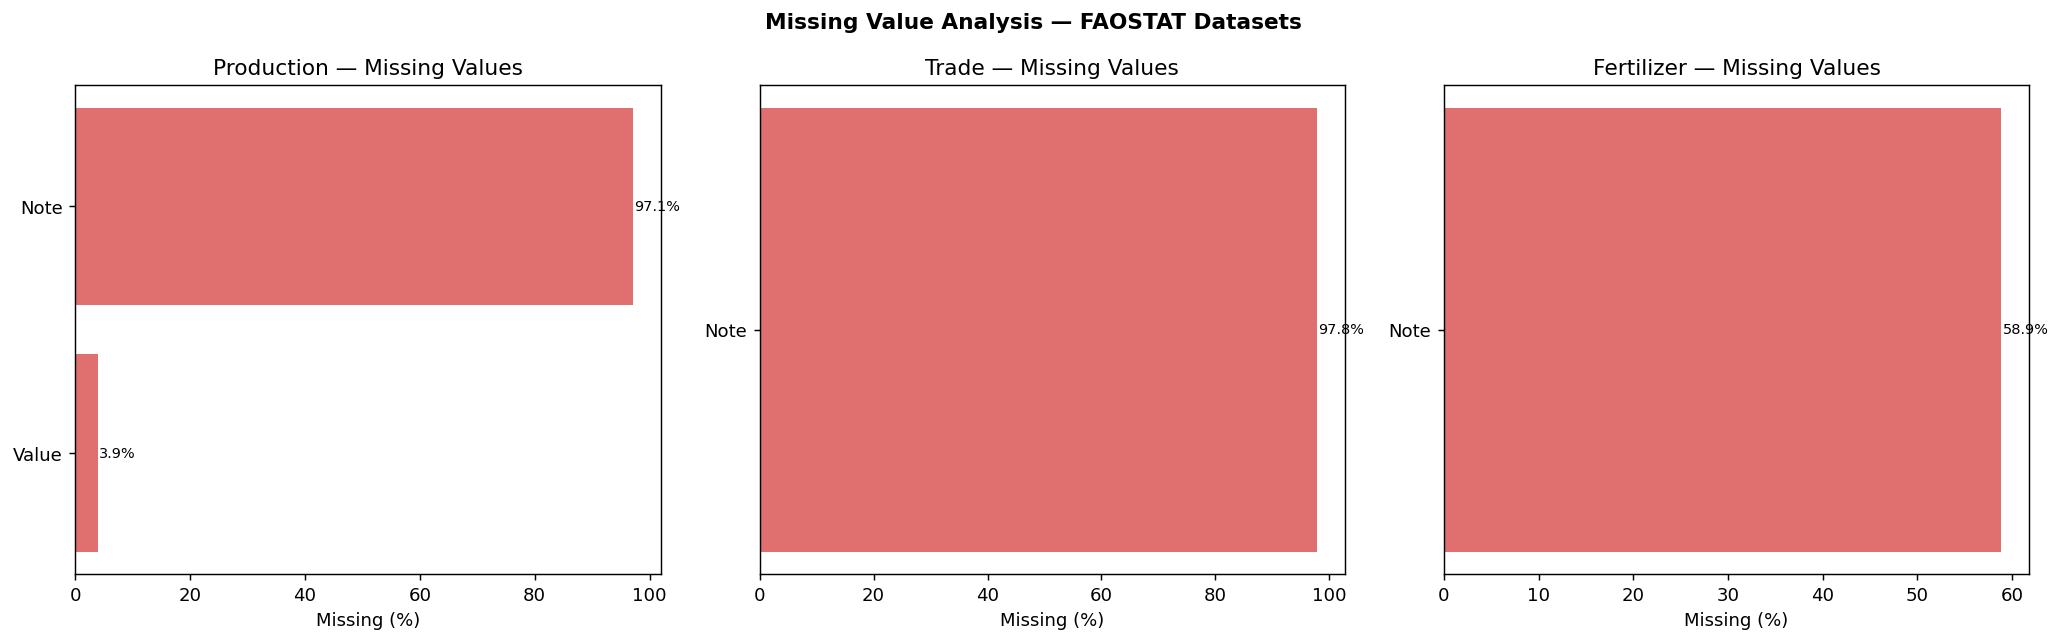

Key finding: 'Value' column has missings coded as flags (<, S) — not true nulls in most cases.


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (df, name) in zip(axes, [
        (df_production, 'Production'),
        (df_trade,      'Trade'),
        (df_fertilizer, 'Fertilizer')]):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) > 0:
        ax.barh(miss.index, miss.values, color='#e07070')
        ax.set_xlabel('Missing (%)')
        ax.set_title(f'{name} — Missing Values')
        for i, v in enumerate(miss.values):
            ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No Missing Values', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='green')
        ax.set_title(f'{name} — Complete')
    ax.invert_yaxis()

plt.suptitle('Missing Value Analysis — FAOSTAT Datasets', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/eda_missing.png', dpi=130, bbox_inches='tight')
plt.show()
print("Key finding: 'Value' column has missings coded as flags (<, S) — not true nulls in most cases.")

### Temporal Coverage and Country Availability

In [50]:
COUNTRIES = ['Ireland','United Kingdom','France','Germany','Netherlands','Denmark']
IRELAND   = 'Ireland'
EU_CNTRS  = ['Ireland','France','Germany','Netherlands','Denmark']

print("=== DATASET TEMPORAL COVERAGE ===")
for df, name in [(df_production,'Production'),(df_trade,'Trade'),
                  (df_fertilizer,'Fertilizer'),(df_organic,'Organic'),(df_landuse,'Land Use')]:
    if 'Year' in df.columns:
        print(f"  {name:12s}: {int(df['Year'].min())}–{int(df['Year'].max())}  |  "
              f"Countries: {df['Area'].nunique()}")

print("\n=== IRELAND RECORD COUNTS ===")
for df, name in [(df_production,'Production'),(df_trade,'Trade'),
                  (df_fertilizer,'Fertilizer'),(df_organic,'Organic'),(df_landuse,'Land Use')]:
    if 'Area' in df.columns:
        n = df[df['Area']=='Ireland'].shape[0]
        print(f"  {name:12s}: {n:,} records")

=== DATASET TEMPORAL COVERAGE ===
  Production  : 1961–2024  |  Countries: 4
  Trade       : 1961–2024  |  Countries: 4
  Fertilizer  : 1961–2023  |  Countries: 4
  Organic     : 2012–2024  |  Countries: 39
  Land Use    : 1961–2025  |  Countries: 4

=== IRELAND RECORD COUNTS ===
  Production  : 14,277 records
  Trade       : 99,406 records
  Fertilizer  : 1,204 records
  Organic     : 13 records
  Land Use    : 1,694 records


### Ireland - Top Agricultural Commodities by Production Volume

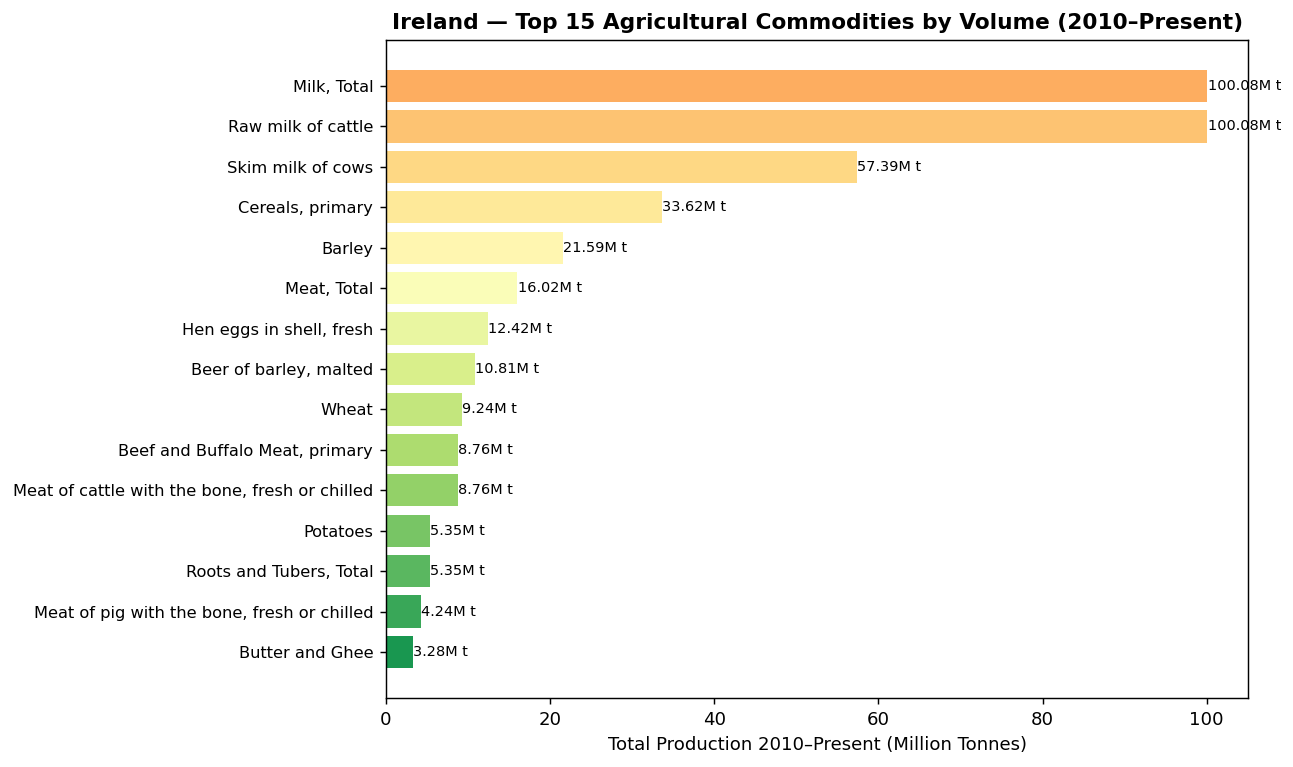

In [51]:
ire_prod = df_production[
    (df_production['Area'] == 'Ireland') &
    (df_production['Element'] == 'Production') &
    (df_production['Year'] >= 2010) &
    (df_production['Value'].notna())
].copy()

top15 = ire_prod.groupby('Item')['Value'].sum().nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
bars = ax.barh(range(15), top15.values / 1e6, color=colors_bar)
ax.set_yticks(range(15))
ax.set_yticklabels(top15.index, fontsize=9)
ax.set_xlabel('Total Production 2010–Present (Million Tonnes)')
ax.set_title("Ireland — Top 15 Agricultural Commodities by Volume (2010–Present)", fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top15.values / 1e6):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}M t', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('data/eda_top_commodities.png', dpi=130, bbox_inches='tight')
plt.show()

### Distribution Analysis - Production Value (Skewness Check)

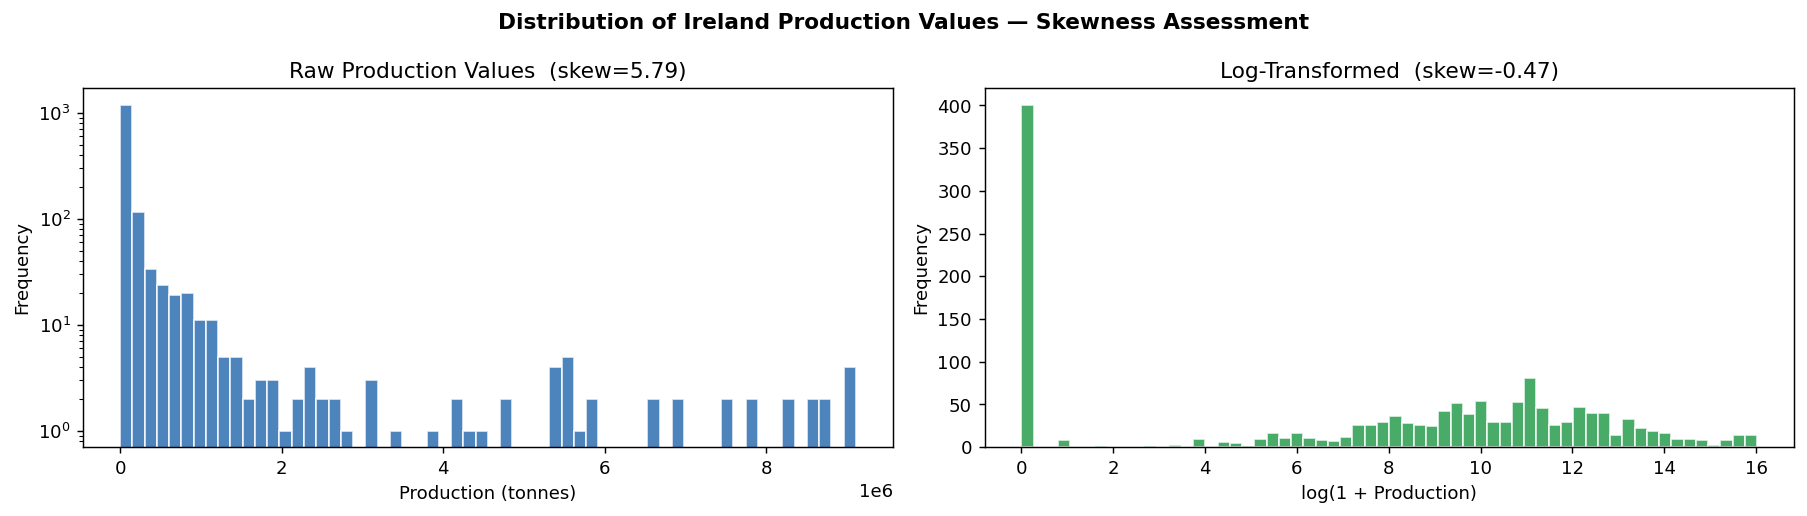

Log transformation recommended for modelling due to high positive skew in raw values.


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vals = ire_prod['Value'].dropna()
axes[0].hist(vals, bins=60, color='#2166ac', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Raw Production Values  (skew={vals.skew():.2f})')
axes[0].set_xlabel('Production (tonnes)')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

log_vals = np.log1p(vals)
axes[1].hist(log_vals, bins=60, color='#1a9641', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Log-Transformed  (skew={log_vals.skew():.2f})')
axes[1].set_xlabel('log(1 + Production)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Distribution of Ireland Production Values — Skewness Assessment', fontweight='bold')
plt.tight_layout()
plt.savefig('data/eda_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("Log transformation recommended for modelling due to high positive skew in raw values.")

### Outlier Detection - Ireland Cow Milk Production (IQR Method)

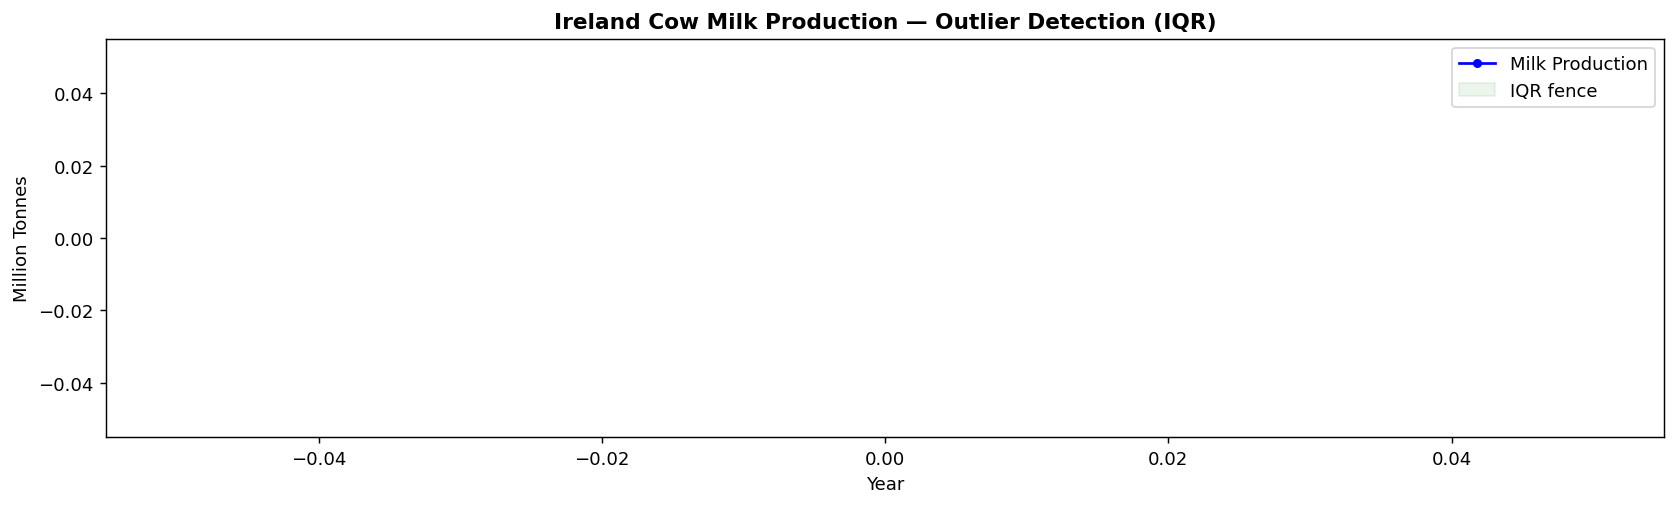

Outliers detected: 0


In [53]:
milk_ts = df_production[
    (df_production['Area'] == 'Ireland') &
    (df_production['Item'] == 'Milk, whole fresh cow') &
    (df_production['Element'] == 'Production') &
    (df_production['Value'].notna())
].sort_values('Year').copy()

Q1  = milk_ts['Value'].quantile(0.25)
Q3  = milk_ts['Value'].quantile(0.75)
IQR = Q3 - Q1
outliers = milk_ts[(milk_ts['Value'] < Q1-1.5*IQR) | (milk_ts['Value'] > Q3+1.5*IQR)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(milk_ts['Year'], milk_ts['Value']/1e6, 'b-o', ms=4, label='Milk Production')
if len(outliers):
    ax.scatter(outliers['Year'], outliers['Value']/1e6, color='red', zorder=6,
               s=90, label=f'Outliers (n={len(outliers)})')
ax.axhspan((Q1-1.5*IQR)/1e6, (Q3+1.5*IQR)/1e6, alpha=0.08, color='green', label='IQR fence')
ax.set_title("Ireland Cow Milk Production — Outlier Detection (IQR)", fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Million Tonnes'); ax.legend()
plt.tight_layout()
plt.savefig('data/eda_outliers.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Outliers detected: {len(outliers)}")
if len(outliers): print(outliers[['Year','Value']])

### Trade Data EDA - Ireland Export vs Import Distribution

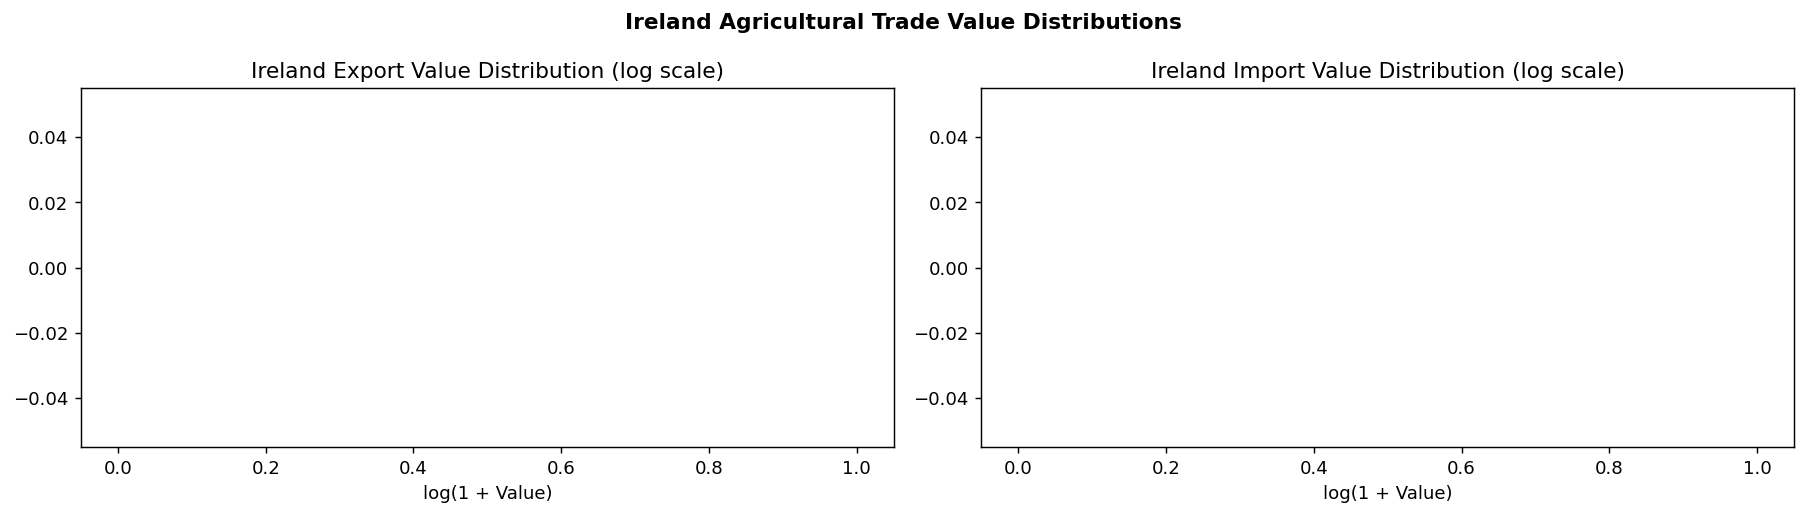

In [54]:
ire_trade_raw = df_trade[
    (df_trade['Area'] == 'Ireland') &
    (df_trade['Element'].isin(['Export Value','Import Value'])) &
    (df_trade['Value'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, elem, color in zip(axes,
        ['Export Value','Import Value'], ['steelblue','coral']):
    d = ire_trade_raw[ire_trade_raw['Element']==elem]['Value']
    ax.hist(np.log1p(d), bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'Ireland {elem} Distribution (log scale)')
    ax.set_xlabel('log(1 + Value)')
plt.suptitle('Ireland Agricultural Trade Value Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('data/eda_trade_dist.png', dpi=130, bbox_inches='tight')
plt.show()

## Data Cleaning & Feature Engineering
Addressing issues identified in EDA: flag-coded missing values, inconsistent encodings, duplicate year-country-item records, and building derived analytical features.

### Clean Production Dataset

In [55]:
KEY_COMMODITIES = {
    "Milk, whole fresh cow": "milk_prod",
    "Cattle": "cattle_head",
    "Meat, cattle": "beef_prod",
    "Cereals, Total": "cereals_prod",
    "Potatoes": "potatoes_prod",
    "Wheat": "wheat_prod",
}

required_cols = {"Area", "Item", "Element", "Year", "Value"}
missing_cols = required_cols - set(df_production.columns)
if missing_cols:
    raise KeyError(f"Production dataset is missing required columns: {missing_cols}")

df_prod_clean = df_production[df_production["Area"].isin(COUNTRIES)].copy()

# Drop rows where Value is null and FAOSTAT flagged the observation as suppressed/sensitive.
# Some FAOSTAT exports may not include a Flag column, so handle this safely.
if "Flag" in df_prod_clean.columns:
    df_prod_clean = df_prod_clean[
        ~((df_prod_clean["Value"].isna()) & (df_prod_clean["Flag"].isin(["<", "S"])))
    ].copy()

sort_cols = [c for c in ["Area", "Item", "Element", "Year", "Flag"] if c in df_prod_clean.columns]
df_prod_clean = (
    df_prod_clean
    .sort_values(sort_cols)
    .drop_duplicates(subset=["Area", "Item", "Element", "Year"], keep="last")
)

df_prod_clean.rename(
    columns={
        "Area": "country",
        "Item": "commodity",
        "Element": "element",
        "Year": "year",
        "Unit": "unit",
        "Value": "value",
    },
    inplace=True,
)

df_prod_clean["year"] = pd.to_numeric(df_prod_clean["year"], errors="coerce").astype("Int64")
df_prod_clean["value"] = pd.to_numeric(df_prod_clean["value"], errors="coerce")

print(f"Clean production: {df_prod_clean.shape}")
df_prod_clean[["country", "commodity", "element", "year", "value"]].head(5)

Clean production: (78029, 14)


,country,commodity,element,year,value
0,Denmark,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,1961,85.0
1,Denmark,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,1962,161.0
2,Denmark,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,1963,154.0
3,Denmark,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,1964,135.0
4,Denmark,"Anise, badian, coriander, cumin, caraway, fenn...",Area harvested,1965,192.0


### Clean Trade Dataset & Build Trade Balance View

In [56]:
required_cols = {"Area", "Item", "Element", "Year", "Value"}
missing_cols = required_cols - set(df_trade.columns)
if missing_cols:
    raise KeyError(f"Trade dataset is missing required columns: {missing_cols}")

df_trade_clean = df_trade[df_trade["Area"].isin(COUNTRIES)].copy()
df_trade_clean = df_trade_clean.dropna(subset=["Value"])
df_trade_clean.rename(
    columns={
        "Area": "country",
        "Item": "commodity",
        "Element": "element",
        "Year": "year",
        "Unit": "unit",
        "Value": "value",
    },
    inplace=True,
)

df_trade_clean["year"] = pd.to_numeric(df_trade_clean["year"], errors="coerce").astype("Int64")
df_trade_clean["value"] = pd.to_numeric(df_trade_clean["value"], errors="coerce")

print("Trade element values:")
print(df_trade_clean["element"].value_counts().head(10))

available_elements = df_trade_clean["element"].dropna().astype(str).unique().tolist()

exp_col = next((e for e in available_elements if "export" in e.lower() and "value" in e.lower()), None)
imp_col = next((e for e in available_elements if "import" in e.lower() and "value" in e.lower()), None)

if exp_col is None or imp_col is None:
    raise ValueError(
        "Could not identify export/import value rows. "
        f"Available trade elements include: {available_elements[:20]}"
    )

print(f"\nUsing: export='{exp_col}' | import='{imp_col}'")

trade_agg = (
    df_trade_clean[df_trade_clean["element"].isin([exp_col, imp_col])]
    .groupby(["country", "year", "element"], dropna=False)["value"]
    .sum()
    .unstack("element", fill_value=0)
    .reset_index()
)

trade_agg.columns.name = None
trade_agg = trade_agg.rename(columns={exp_col: "export_val", imp_col: "import_val"})

for col in ["export_val", "import_val"]:
    if col not in trade_agg.columns:
        trade_agg[col] = 0.0

trade_agg["trade_balance"] = trade_agg["export_val"] - trade_agg["import_val"]

print(f"\nTrade balance dataset: {trade_agg.shape}")
trade_agg[trade_agg["country"] == "Ireland"].tail(5)

Trade element values:
element
Import value       105210
Export value       103327
Import quantity    101975
Export quantity     99810
Name: count, dtype: int64

Using: export='Export value' | import='Import value'

Trade balance dataset: (256, 5)


,country,year,export_val,import_val,trade_balance
251,Ireland,2020,2.584107e+08,1.514297e+08,1.069810e+08
252,Ireland,2021,2.764805e+08,1.695612e+08,1.069193e+08
253,Ireland,2022,3.098520e+08,2.036502e+08,1.062018e+08
254,Ireland,2023,3.046838e+08,2.105963e+08,9.408753e+07
255,Ireland,2024,3.409516e+08,2.094352e+08,1.315164e+08


### Create Master Analysis Dataset

In [57]:
# Pivot key commodities to wide format
prod_subset = df_prod_clean[
    df_prod_clean["commodity"].isin(KEY_COMMODITIES.keys())
    & (df_prod_clean["element"] == "Production")
    & (df_prod_clean["year"] >= 2000)
].copy()

if prod_subset.empty:
    raise ValueError("No key production records were found. Check commodity names and FAOSTAT data coverage.")

prod_subset["commodity"] = prod_subset["commodity"].replace(KEY_COMMODITIES)

prod_wide = (
    prod_subset
    .pivot_table(index=["country", "year"], columns="commodity", values="value", aggfunc="sum")
    .reset_index()
)

master = pd.merge(prod_wide, trade_agg, on=["country", "year"], how="left")
master["is_ireland"] = (master["country"] == "Ireland").astype(int)
master["is_eu"] = (~master["country"].isin(["United Kingdom"])).astype(int)

print(f"Master dataset: {master.shape}")
print(f"Columns: {master.columns.tolist()}")
master.head(4)

Master dataset: (100, 9)
Columns: ['country', 'year', 'potatoes_prod', 'wheat_prod', 'export_val', 'import_val', 'trade_balance', 'is_ireland', 'is_eu']


,country,year,potatoes_prod,wheat_prod,export_val,import_val,trade_balance,is_ireland,is_eu
0,Denmark,2000,1645240.0,4693422.0,9.592933e+07,66688445.39,29240885.72,0,1
1,Denmark,2001,1543028.0,4663938.0,9.813763e+07,66770384.62,31367246.15,0,1
2,Denmark,2002,1504200.0,4056240.0,1.070107e+08,74883832.51,32126863.10,0,1
3,Denmark,2003,1412200.0,4701382.0,1.242425e+08,87290130.18,36952396.47,0,1


### Save Cleaned Data to CSV and Update SQLite

In [58]:
df_prod_clean.to_csv(DATA_DIR / "production_clean.csv", index=False)
df_trade_clean.to_csv(DATA_DIR / "trade_clean.csv", index=False)
trade_agg.to_csv(DATA_DIR / "trade_balance.csv", index=False)
master.to_csv(DATA_DIR / "master_dataset.csv", index=False)

if "engine" in globals() and engine is not None:
    for name, df in [
        ("production_clean", df_prod_clean),
        ("trade_clean", df_trade_clean),
        ("trade_balance", trade_agg),
        ("master_dataset", master),
    ]:
        df.to_sql(name, engine, if_exists="replace", index=False, chunksize=5000)
        print(f"Saved '{name}' to database.")
else:
    print("Database engine not available; CSV files were saved only.")

print("All cleaned datasets saved.")

Saved 'production_clean' to database.
Saved 'trade_clean' to database.
Saved 'trade_balance' to database.
Saved 'master_dataset' to database.
All cleaned datasets saved.


## Descriptive Statistics & Visualisation
Summarising Ireland's agricultural profile and contextualising it against comparator countries.

### Summary Statistics - Ireland Master Dataset

In [59]:
ire_master = master[master['country']=='Ireland'].sort_values('year')
print("=== IRELAND AGRICULTURAL SUMMARY STATISTICS (2000–Present) ===\n")
print(ire_master.drop(columns=['country','is_ireland','is_eu']).describe().round(2).to_string())

=== IRELAND AGRICULTURAL SUMMARY STATISTICS (2000–Present) ===

         year  potatoes_prod  wheat_prod    export_val    import_val  trade_balance
count    25.0          25.00       25.00  2.500000e+01  2.500000e+01   2.500000e+01
mean   2012.0      388413.80   697135.16  1.999485e+08  1.238351e+08   7.611343e+07
std      7.36       72943.71   164668.20  6.128145e+07  4.200614e+07   2.104047e+07
min    2000.0      232000.00   364920.00  1.132962e+08  6.698483e+07   4.533881e+07
25%    2006.0      352000.00   628080.00  1.676004e+08  9.660955e+07   6.425187e+07
50%    2012.0      382900.00   701240.00  1.873622e+08  1.195345e+08   7.054883e+07
75%    2018.0      412425.00   794100.00  2.434334e+08  1.492662e+08   8.373862e+07
max    2024.0      552200.00  1019200.00  3.409516e+08  2.105963e+08   1.315164e+08


### Milk Production Trend - Ireland vs Comparators
The EU milk quota was abolished in 2015, creating a natural experiment in deregulation. This chart highlights Ireland's response.

Milk commodities found:
['Butter of cow milk', 'Buttermilk, dry', 'Cheese from milk of buffalo, fresh or processed', 'Cheese from milk of goats, fresh or processed', 'Cheese from milk of sheep, fresh or processed', 'Cheese from whole cow milk', 'Evaporated & Condensed Milk', 'Milk, Total', 'Raw milk of buffalo', 'Raw milk of cattle', 'Raw milk of goats', 'Raw milk of sheep', 'Skim Milk & Buttermilk, Dry', 'Skim milk and whey powder', 'Skim milk of cows', 'Whole milk powder', 'Whole milk, condensed', 'Whole milk, evaporated', 'Cheese from skimmed cow milk', 'Skim milk, evaporated']


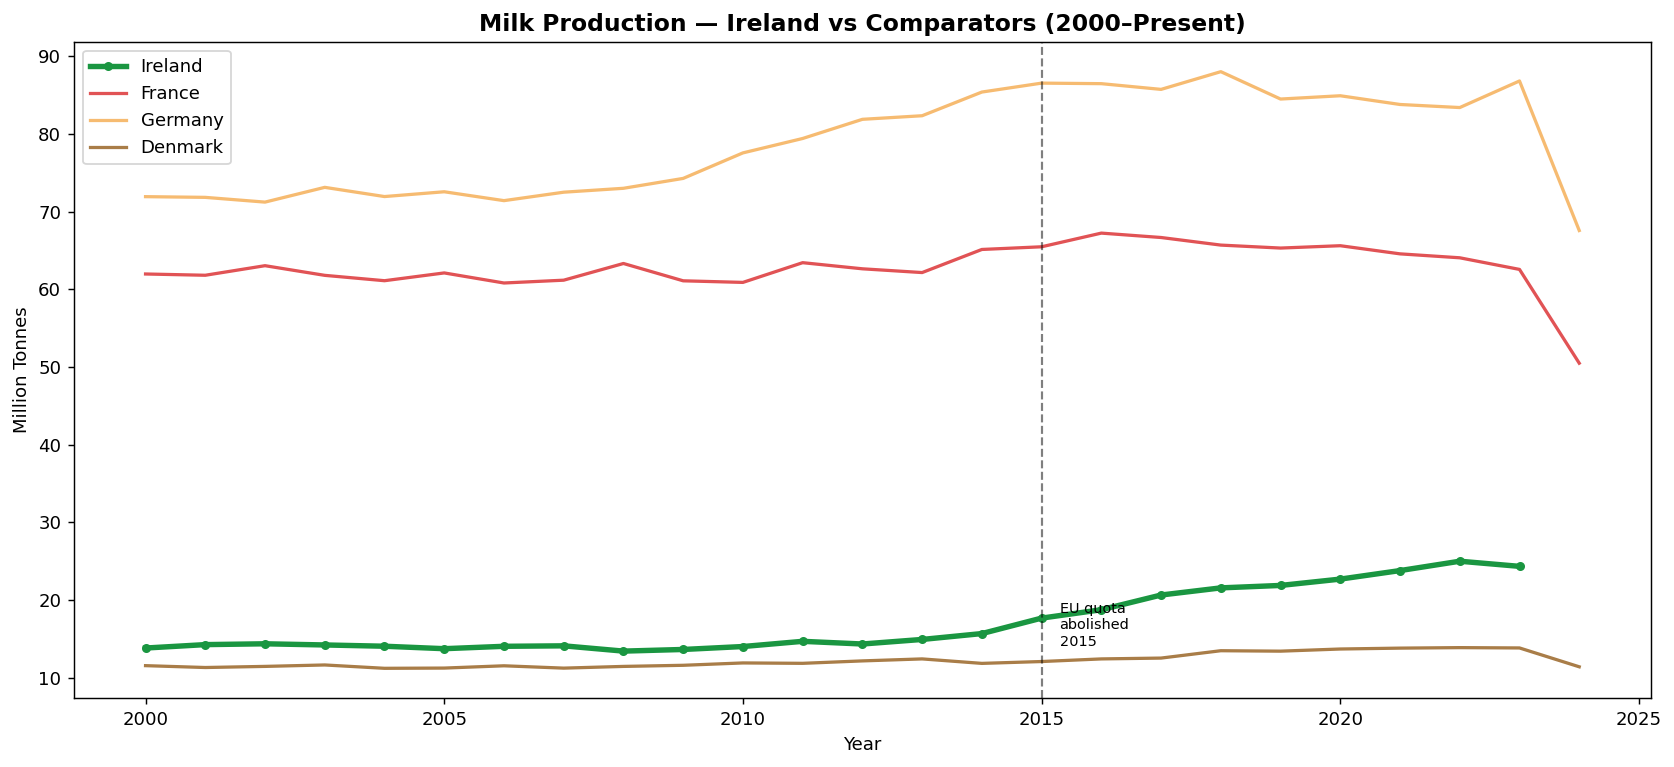

Ireland pre-quota-abolition avg  : 14.41M tonnes
Ireland post-quota-abolition avg : 22.31M tonnes (+54.8%)


In [61]:
# Safer milk filter because FAOSTAT commodity names can be slightly different
milk_mask = (
    df_prod_clean["commodity"].astype(str).str.lower().str.contains("milk", na=False)
    & df_prod_clean["element"].astype(str).str.lower().eq("production")
    & (df_prod_clean["year"] >= 2000)
)

milk_data = df_prod_clean[milk_mask].copy()

print("Milk commodities found:")
print(milk_data["commodity"].drop_duplicates().tolist())

# Aggregate in case there are multiple milk-related commodity names
milk_data = (
    milk_data
    .groupby(["country", "year"], as_index=False)["value"]
    .sum()
)

CLR = {
    "Ireland": "#1a9641",
    "United Kingdom": "#2166ac",
    "France": "#d7191c",
    "Germany": "#f4a442",
    "Netherlands": "#762a83",
    "Denmark": "#8c510a",
}

fig, ax = plt.subplots(figsize=(13, 6))

plotted = False

for country in COUNTRIES:
    d = milk_data[milk_data["country"] == country].sort_values("year")

    if not d.empty:
        plotted = True
        ax.plot(
            d["year"],
            d["value"] / 1e6,
            color=CLR.get(country, "gray"),
            linewidth=3 if country == "Ireland" else 1.8,
            marker="o" if country == "Ireland" else None,
            markersize=4,
            label=country,
            alpha=1 if country == "Ireland" else 0.75,
        )

if plotted:
    ax.axvline(2015, color="black", lw=1.2, ls="--", alpha=0.5)

    ymin, ymax = ax.get_ylim()
    ax.text(
        2015.3,
        ymin + ((ymax - ymin) * 0.08),
        "EU quota\nabolished\n2015",
        fontsize=8,
        color="black",
    )

    ax.set_title(
        "Milk Production — Ireland vs Comparators (2000–Present)",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Million Tonnes")
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(DATA_DIR / "stat_milk_trend.png", dpi=130, bbox_inches="tight")
    plt.show()

    pre = milk_data[
        (milk_data["country"] == "Ireland")
        & (milk_data["year"] <= 2015)
    ]["value"].mean()

    post = milk_data[
        (milk_data["country"] == "Ireland")
        & (milk_data["year"] > 2015)
    ]["value"].mean()

    if pd.notna(pre) and pd.notna(post) and pre != 0:
        print(f"Ireland pre-quota-abolition avg  : {pre/1e6:.2f}M tonnes")
        print(f"Ireland post-quota-abolition avg : {post/1e6:.2f}M tonnes (+{(post-pre)/pre*100:.1f}%)")
    else:
        print("Not enough Ireland milk records to calculate pre/post quota averages.")

else:
    plt.close(fig)

    print("No milk production records found after filtering.")
    print("\nAvailable production commodities containing 'milk':")
    print(
        df_prod_clean[
            df_prod_clean["commodity"].astype(str).str.lower().str.contains("milk", na=False)
        ]["commodity"].drop_duplicates().head(30).tolist()
    )

### Ireland Agricultural Trade Balance (2000-Present)

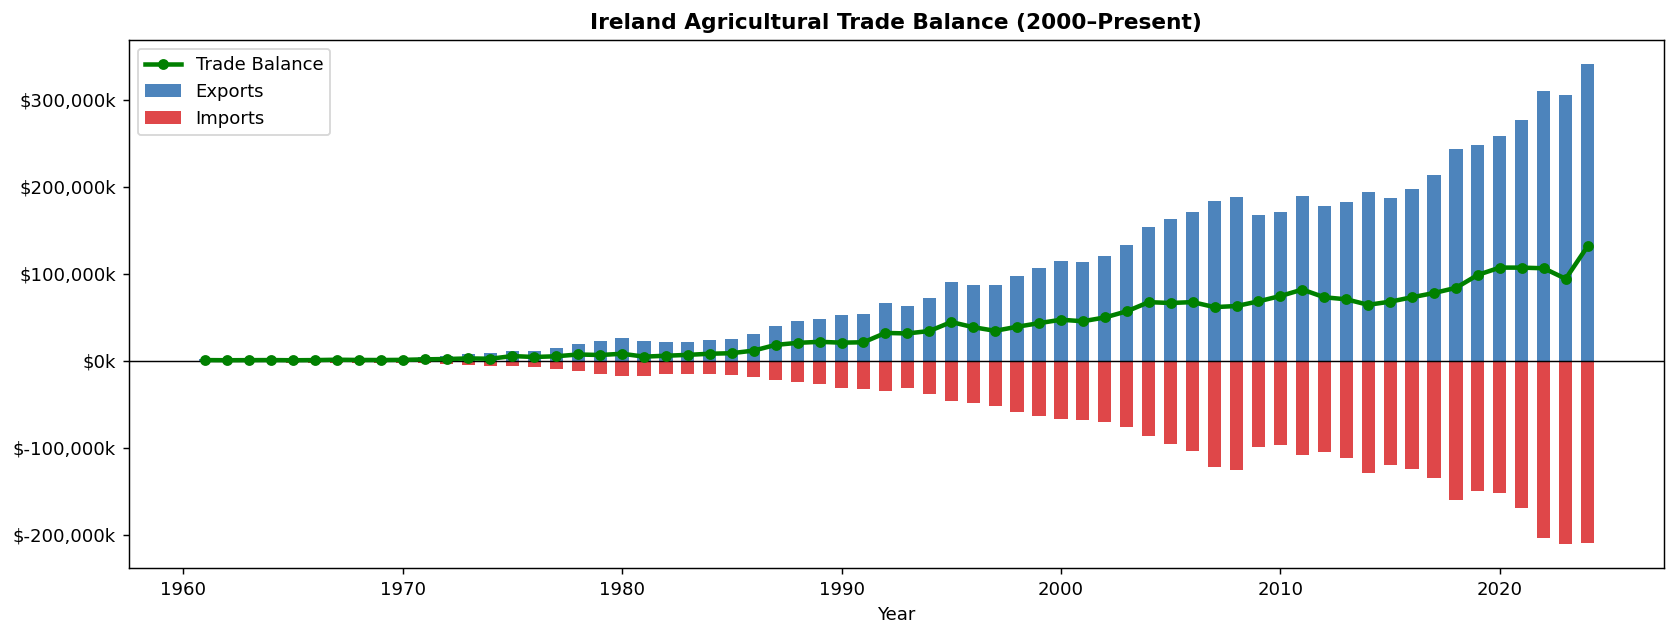

Mean annual trade surplus: $37,513k USD


In [62]:
ire_trade_yr = trade_agg[trade_agg['country']=='Ireland'].sort_values('year')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(ire_trade_yr['year'], ire_trade_yr['export_val']/1e3,
       label='Exports', color='#2166ac', alpha=0.8, width=0.6)
ax.bar(ire_trade_yr['year'], -ire_trade_yr['import_val']/1e3,
       label='Imports', color='#d7191c', alpha=0.8, width=0.6)
ax.plot(ire_trade_yr['year'], ire_trade_yr['trade_balance']/1e3,
        'g-o', lw=2.5, ms=5, zorder=5, label='Trade Balance')
ax.axhline(0, color='black', lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}k'))
ax.set_title("Ireland Agricultural Trade Balance (2000–Present)", fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.legend()
plt.tight_layout()
plt.savefig('data/stat_trade_balance.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Mean annual trade surplus: ${ire_trade_yr['trade_balance'].mean()/1e3:,.0f}k USD")

### Organic Farming - Ireland vs EU Countries

Organic dataset columns: ['Area', 'geo_code', 'Year', 'Value', 'Unit', 'Element', 'Item', 'Flag']
Elements: ['Organic utilised agricultural area']


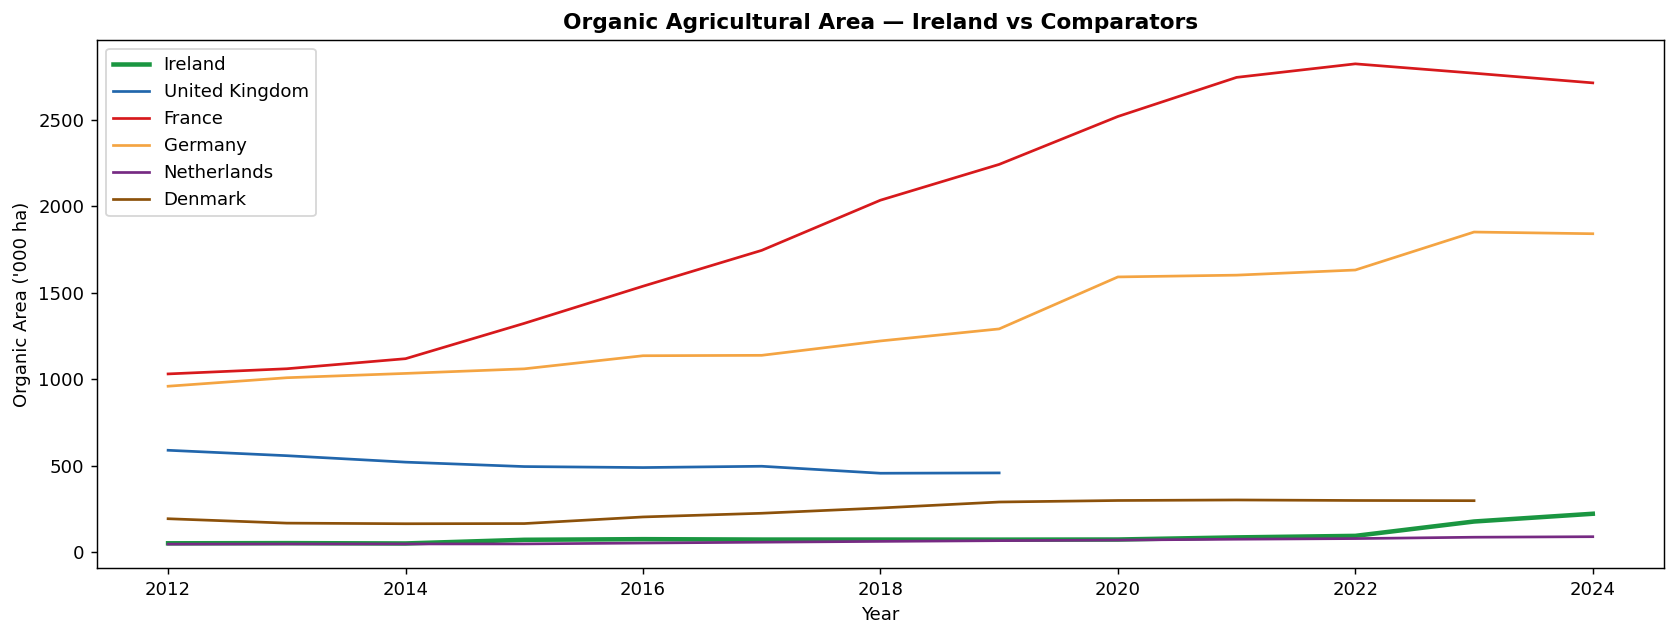

In [63]:
# Identify available elements
org_cols = ['Area','Item','Element','Year','Value'] if all(
    c in df_organic.columns for c in ['Area','Item','Element','Year','Value']) else df_organic.columns.tolist()
print("Organic dataset columns:", df_organic.columns.tolist())
print("Elements:", df_organic['Element'].unique()[:10] if 'Element' in df_organic.columns else 'N/A')

org = df_organic[df_organic['Area'].isin(COUNTRIES)].copy() if 'Area' in df_organic.columns else df_organic.copy()

if 'Element' in org.columns and 'Year' in org.columns and 'Value' in org.columns:
    # Try to find organic area under cultivation
    area_elem = [e for e in org['Element'].unique() if 'area' in e.lower() or 'hectare' in e.lower()]
    if area_elem:
        org_area = org[org['Element'].isin(area_elem)].groupby(['Area','Year'])['Value'].sum().reset_index()
        fig, ax = plt.subplots(figsize=(13, 5))
        for c in COUNTRIES:
            d = org_area[org_area['Area']==c].sort_values('Year')
            if len(d):
                ax.plot(d['Year'], d['Value']/1e3, label=c, color=CLR.get(c,'gray'),
                        linewidth=2.5 if c=='Ireland' else 1.5)
        ax.set_title("Organic Agricultural Area — Ireland vs Comparators", fontweight='bold')
        ax.set_xlabel('Year'); ax.set_ylabel("Organic Area ('000 ha)"); ax.legend()
        plt.tight_layout()
        plt.savefig('data/stat_organic.png', dpi=130, bbox_inches='tight')
        plt.show()
    else:
        print("Available elements:", org['Element'].value_counts().head(10))
else:
    print("Dataset structure review required:", org.head(3))

### Fertilizer Use Intensity - Country Comparison

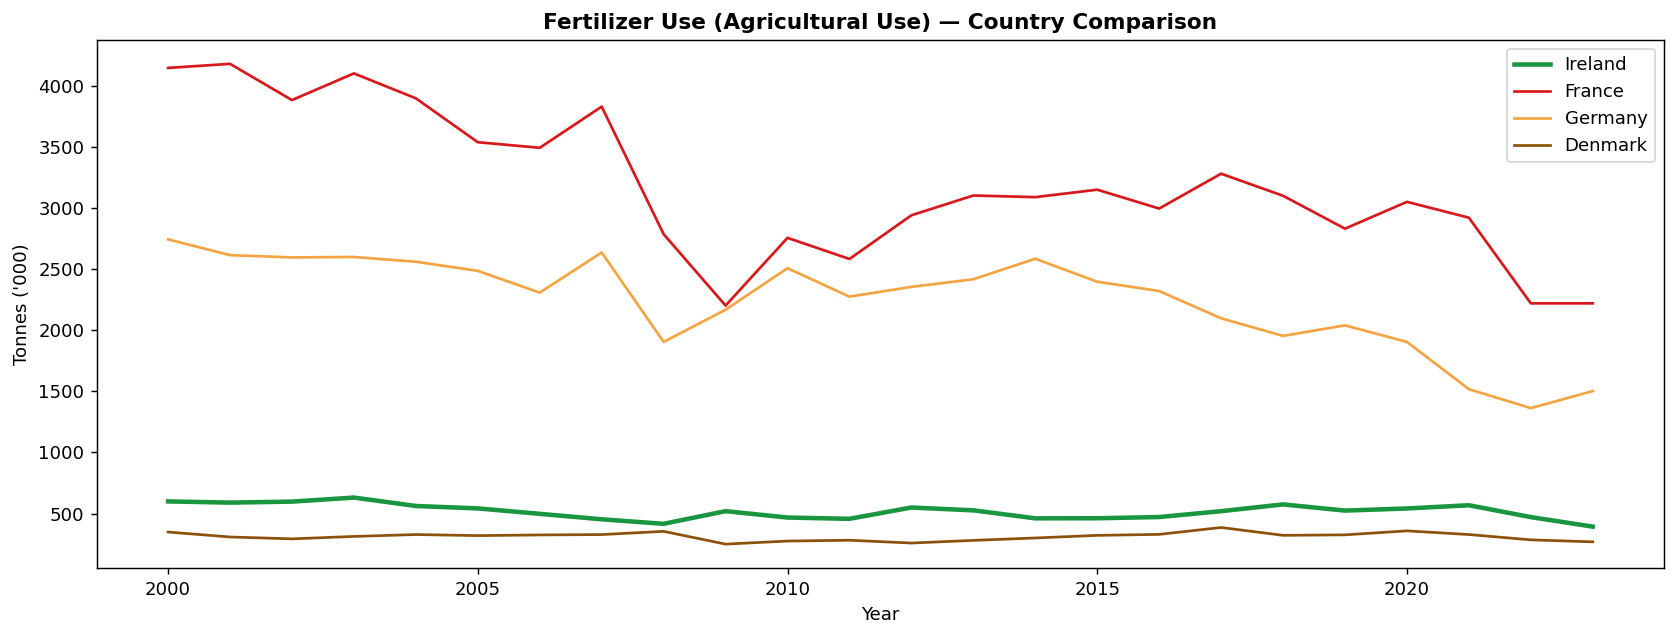

In [64]:
fert = df_fertilizer[df_fertilizer["Area"].isin(COUNTRIES)].copy() if "Area" in df_fertilizer.columns else df_fertilizer.copy()

needed = {"Element", "Year", "Value", "Area"}
if needed.issubset(fert.columns):
    fert["Year"] = pd.to_numeric(fert["Year"], errors="coerce")
    fert["Value"] = pd.to_numeric(fert["Value"], errors="coerce")

    element_options = fert["Element"].dropna().astype(str).unique().tolist()
    preferred = [
        e for e in element_options
        if ("agricultural use" in e.lower()) or ("use per area" in e.lower()) or ("nutrient nitrogen" in e.lower())
    ]
    elem_col = preferred[0] if preferred else element_options[0]

    fert_ag = (
        fert[(fert["Element"] == elem_col) & (fert["Year"] >= 2000)]
        .groupby(["Area", "Year"])["Value"]
        .sum()
        .reset_index()
    )

    if fert_ag.empty:
        print(f"No fertilizer records available for element '{elem_col}' from 2000 onwards.")
    else:
        fig, ax = plt.subplots(figsize=(13, 5))
        for country in COUNTRIES:
            d = fert_ag[fert_ag["Area"] == country].sort_values("Year")
            if not d.empty:
                ax.plot(
                    d["Year"],
                    d["Value"] / 1e3,
                    label=country,
                    color=CLR.get(country, "gray"),
                    linewidth=2.5 if country == "Ireland" else 1.5,
                )
        ax.set_title(f"Fertilizer Use ({elem_col}) — Country Comparison", fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("Tonnes ('000)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(DATA_DIR / "stat_fertilizer.png", dpi=130, bbox_inches="tight")
        plt.show()
else:
    print("Fertilizer dataset does not have the expected structure.")
    print(fert.head())

### Correlation Matrix - Ireland Agricultural Variables

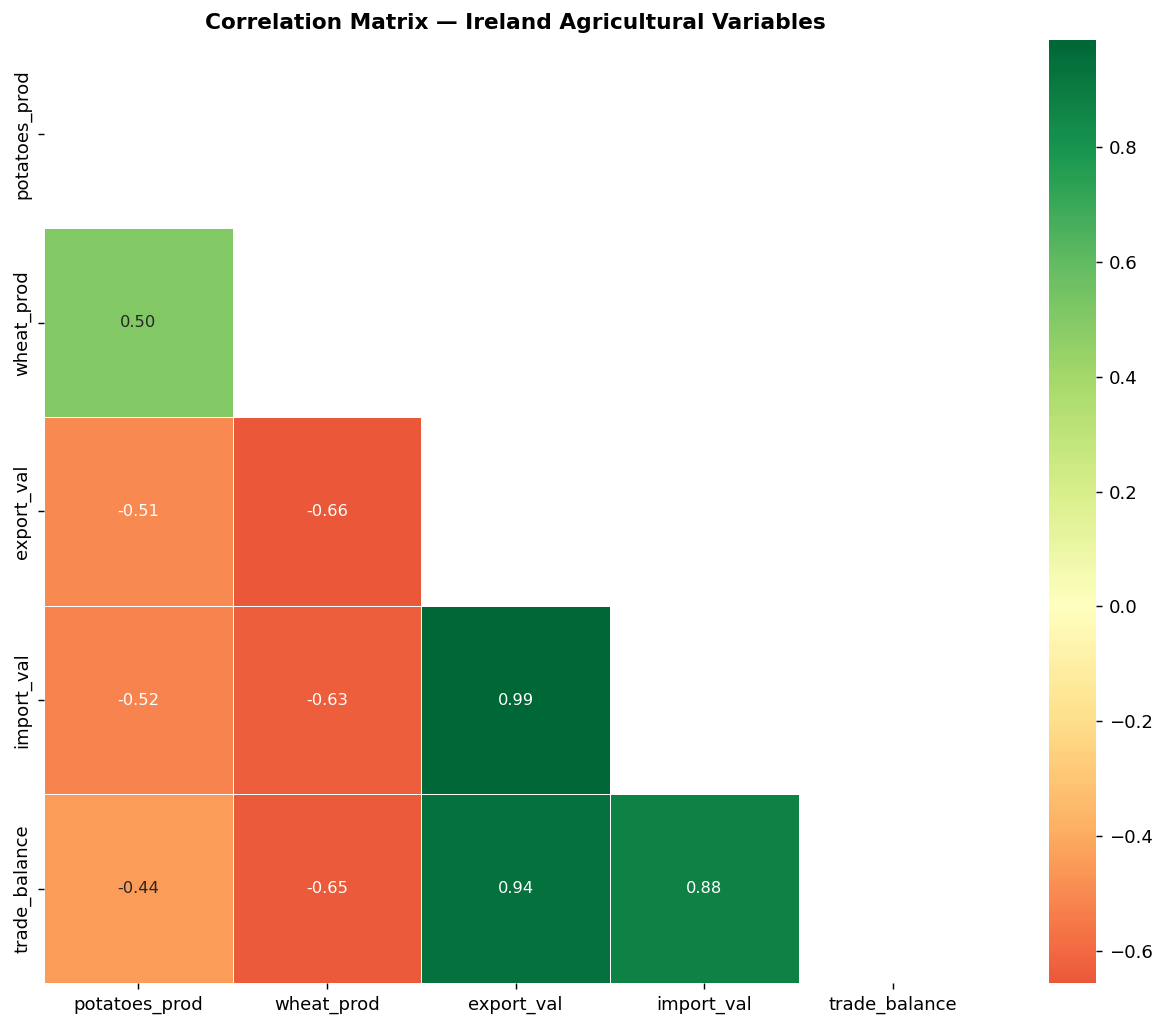

In [65]:
ire_num = ire_master.select_dtypes(include=np.number).drop(columns=['year','is_ireland','is_eu'], errors='ignore').dropna(axis=1, thresh=5).dropna()
if ire_num.shape[1] > 1:
    corr = ire_num.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.4, ax=ax, annot_kws={'size':9})
    ax.set_title("Correlation Matrix — Ireland Agricultural Variables", fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/stat_corr_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient numeric columns after filtering. Check master dataset completeness.")

## Inferential Statistics
Using sampling theory to make evidence-based generalisations. Seven distinct tests are applied, covering both parametric (normality assumed) and non-parametric (distribution-free) approaches.

### Confidence Interval - Ireland Mean Annual Agricultural Export Value
Estimating the true population mean of Ireland's annual agricultural export value with 95% confidence using the t-distribution (sample < 30 years).

In [66]:
ire_exp = trade_agg[trade_agg["country"] == "Ireland"]["export_val"].dropna()

n = len(ire_exp)
mean = ire_exp.mean() if n else np.nan

print("=== 95% CONFIDENCE INTERVAL — Ireland Annual Agricultural Export Value ===")
print(f"Sample n        : {n}")

if n >= 2:
    se = stats.sem(ire_exp)
    ci = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

    print(f"Sample mean     : ${mean/1e3:,.1f}k USD")
    print(f"Std error       : ${se/1e3:,.1f}k USD")
    print(f"95% CI          : (${ci[0]/1e3:,.1f}k, ${ci[1]/1e3:,.1f}k)")
    print("\nInterpretation  : With 95% confidence, Ireland's true mean annual agricultural export")
    print(f"                  value lies between ${ci[0]/1e3:,.0f}k and ${ci[1]/1e3:,.0f}k USD.")
else:
    se = np.nan
    ci = (np.nan, np.nan)
    print("Not enough export records to calculate a confidence interval.")

=== 95% CONFIDENCE INTERVAL — Ireland Annual Agricultural Export Value ===
Sample n        : 64
Sample mean     : $97,034.0k USD
Std error       : $11,806.0k USD
95% CI          : ($73,441.6k, $120,626.5k)

Interpretation  : With 95% confidence, Ireland's true mean annual agricultural export
                  value lies between $73,442k and $120,627k USD.


### Test 1 - Independent Samples t-Test: Ireland vs UK Cow Milk Production
**H₀:** μ_Ireland = μ_UK (no difference in mean annual milk production)
**H₁:** μ_Ireland ≠ μ_UK (two-tailed)
Levene's test used to determine equal-variance assumption.

In [67]:
ire_milk_v = milk_data[milk_data["country"] == "Ireland"]["value"].dropna()
uk_milk_v = milk_data[milk_data["country"] == "United Kingdom"]["value"].dropna()

print("=== TEST 1: Independent t-Test — Ireland vs UK Milk Production ===")

if len(ire_milk_v) >= 2 and len(uk_milk_v) >= 2:
    if len(ire_milk_v) >= 3 and len(uk_milk_v) >= 3:
        _, p_norm_ire = shapiro(ire_milk_v)
        _, p_norm_uk = shapiro(uk_milk_v)
        print(f"Shapiro-Wilk: Ireland p={p_norm_ire:.4f} | UK p={p_norm_uk:.4f}")
    else:
        print("Shapiro-Wilk skipped because at least 3 observations are required.")

    _, p_lev = levene(ire_milk_v, uk_milk_v)
    equal_var = p_lev > 0.05
    print(f"Levene's test p={p_lev:.4f} → equal_var={equal_var}")

    t_stat, p_t = ttest_ind(ire_milk_v, uk_milk_v, equal_var=equal_var)
    print(f"t-statistic : {t_stat:.4f}")
    print(f"p-value     : {p_t:.6f}")
    print(f"Ireland mean: {ire_milk_v.mean()/1e6:.3f}M t | UK mean: {uk_milk_v.mean()/1e6:.3f}M t")
    print(
        "Conclusion  :",
        "REJECT H₀" if p_t < 0.05 else "FAIL TO REJECT H₀",
        f"(α=0.05) — {'significant difference detected' if p_t < 0.05 else 'no significant difference'}",
    )
else:
    p_t = np.nan
    print("Insufficient Ireland or UK milk records for an independent t-test.")

=== TEST 1: Independent t-Test — Ireland vs UK Milk Production ===
Insufficient Ireland or UK milk records for an independent t-test.


### Test 2 - Mann-Whitney U Test: Ireland vs France Beef Production
**Non-parametric** alternative to t-test; no normality assumed.
**H₀:** The beef production distributions of Ireland and France are identical.
**H₁:** Distributions differ.

In [68]:
beef_data = df_prod_clean[
    (df_prod_clean["commodity"] == "Meat, cattle")
    & (df_prod_clean["element"] == "Production")
    & (df_prod_clean["value"].notna())
].copy()

ire_beef = beef_data[beef_data["country"] == "Ireland"]["value"]
fra_beef = beef_data[beef_data["country"] == "France"]["value"]

print("=== TEST 2: Mann-Whitney U — Ireland vs France Beef Production ===")

if len(ire_beef) >= 2 and len(fra_beef) >= 2:
    u_stat, p_mw = mannwhitneyu(ire_beef, fra_beef, alternative="two-sided")
    print(f"U-statistic : {u_stat:.2f}")
    print(f"p-value     : {p_mw:.6f}")
    print(f"Ireland median: {ire_beef.median()/1e3:.1f}k t | France median: {fra_beef.median()/1e3:.1f}k t")
    print("Conclusion  :", "REJECT H₀" if p_mw < 0.05 else "FAIL TO REJECT H₀", "(α=0.05)")
else:
    p_mw = np.nan
    print("Insufficient Ireland or France beef records for Mann-Whitney U test.")

=== TEST 2: Mann-Whitney U — Ireland vs France Beef Production ===
Insufficient Ireland or France beef records for Mann-Whitney U test.


### Test 3 - One-Way ANOVA: Milk Production Across 5 EU Countries
**H₀:** Mean milk production is equal across Ireland, France, Germany, Netherlands, Denmark.
**H₁:** At least one country mean differs.

In [69]:
groups_milk = []
valid_milk_countries = []

for country in EU_CNTRS:
    group = milk_data[milk_data["country"] == country]["value"].dropna().values
    print(f"  {country:12s}: n={len(group):3d}", end="")
    if len(group):
        print(f"  mean={np.mean(group)/1e6:.3f}M t  sd={np.std(group)/1e6:.3f}M t")
    else:
        print("  no data")

    if len(group) >= 2:
        groups_milk.append(group)
        valid_milk_countries.append(country)

print("\n=== TEST 3: One-Way ANOVA — Milk Production ===")

if len(groups_milk) >= 2:
    f_stat, p_anova = f_oneway(*groups_milk)
    print(f"Countries used: {valid_milk_countries}")
    print(f"F-statistic : {f_stat:.4f}")
    print(f"p-value     : {p_anova:.6f}")
    print("Conclusion  :", "REJECT H₀" if p_anova < 0.05 else "FAIL TO REJECT H₀", "(α=0.05)")
    print("Note: If H₀ rejected, post-hoc Tukey HSD would identify which pairs differ.")
else:
    p_anova = np.nan
    print("Insufficient country groups for ANOVA.")

  Ireland     : n= 24  mean=17.047M t  sd=3.971M t
  France      : n= 25  mean=62.814M t  sd=3.142M t
  Germany     : n= 25  mean=78.745M t  sd=6.470M t
  Netherlands : n=  0  no data
  Denmark     : n= 25  mean=12.174M t  sd=0.914M t

=== TEST 3: One-Way ANOVA — Milk Production ===
Countries used: ['Ireland', 'France', 'Germany', 'Denmark']
F-statistic : 1528.1181
p-value     : 0.000000
Conclusion  : REJECT H₀ (α=0.05)
Note: If H₀ rejected, post-hoc Tukey HSD would identify which pairs differ.


### Test 4 - Kruskal-Wallis Test: Fertilizer Use Across All 6 Countries
**Non-parametric** equivalent of one-way ANOVA.
**H₀:** Fertilizer use distributions are identical across all 6 countries.

In [70]:
fert_groups_kw = []
for c in COUNTRIES:
    d = df_fertilizer[df_fertilizer['Area']==c]['Value'].dropna() if 'Area' in df_fertilizer.columns else pd.Series([])
    if len(d) >= 5:
        fert_groups_kw.append(d.values)
        print(f"  {c:15s}: n={len(d):3d}  median={np.median(d):>10,.1f}")

if len(fert_groups_kw) >= 2:
    h_stat, p_kw = kruskal(*fert_groups_kw)
    print(f"\n=== TEST 4: Kruskal-Wallis — Fertilizer Use ({len(fert_groups_kw)} Countries) ===")
    print(f"H-statistic : {h_stat:.4f}")
    print(f"p-value     : {p_kw:.6f}")
    print("Conclusion  :", "REJECT H₀" if p_kw < 0.05 else "FAIL TO REJECT H₀", "(α=0.05)")
else:
    print("Insufficient groups for Kruskal-Wallis — check fertilizer data availability per country.")

  Ireland        : n=1204  median=     154.5
  France         : n=1323  median=  76,788.6
  Germany        : n=1323  median= 119,738.0
  Denmark        : n=1242  median=     146.3

=== TEST 4: Kruskal-Wallis — Fertilizer Use (4 Countries) ===
H-statistic : 287.8437
p-value     : 0.000000
Conclusion  : REJECT H₀ (α=0.05)


### Test 5 - Chi-Squared Test: Organic Farming Adoption vs EU Membership
**H₀:** Organic farming adoption (high/low) is independent of EU membership status.

In [71]:
if {"Area", "Value"}.issubset(df_organic.columns):
    org_recent = df_organic[df_organic["Year"] >= 2018].copy() if "Year" in df_organic.columns else df_organic.copy()
    org_recent["Value"] = pd.to_numeric(org_recent["Value"], errors="coerce")
    org_med = org_recent.dropna(subset=["Value"]).groupby("Area")["Value"].median().reset_index()

    if len(org_med) >= 4:
        global_med = org_med["Value"].median()

        eu_list = [
            "Ireland", "France", "Germany", "Netherlands", "Denmark", "Italy", "Spain",
            "Belgium", "Austria", "Finland", "Sweden", "Portugal", "Greece", "Poland",
            "Czech Republic", "Hungary", "Romania", "Bulgaria",
        ]
        non_eu = [
            "United Kingdom", "United States of America", "Australia", "Canada",
            "Brazil", "Argentina", "China", "India", "Japan", "New Zealand",
        ]

        org_med["membership"] = org_med["Area"].apply(
            lambda x: "EU" if x in eu_list else ("Non-EU" if x in non_eu else None)
        )
        org_med = org_med.dropna(subset=["membership"])
        org_med["adoption"] = (org_med["Value"] >= global_med).map({True: "High", False: "Low"})

        ctab = pd.crosstab(org_med["membership"], org_med["adoption"])
        print("Contingency Table:")
        print(ctab)

        if ctab.shape == (2, 2) and (ctab.values > 0).all():
            chi2, p_chi, dof, expected = chi2_contingency(ctab)
            print("\n=== TEST 5: Chi-Squared — Organic Adoption vs EU Membership ===")
            print(f"χ²-statistic : {chi2:.4f} | df={dof}")
            print(f"p-value      : {p_chi:.6f}")
            print(f"Expected frequencies:\n{pd.DataFrame(expected.round(2), index=ctab.index, columns=ctab.columns)}")
            print("Conclusion   :", "REJECT H₀" if p_chi < 0.05 else "FAIL TO REJECT H₀", "(α=0.05)")
        else:
            p_chi = np.nan
            print("Chi-squared test skipped because the contingency table is not a complete 2x2 table with non-zero cells.")
    else:
        p_chi = np.nan
        print("Insufficient organic records for chi-squared test.")
else:
    p_chi = np.nan
    print("Organic dataset missing required columns — verify faostat_organic.csv structure.")

Contingency Table:
adoption    High  Low
membership           
EU            13    4
Non-EU         1    0
Chi-squared test skipped because the contingency table is not a complete 2x2 table with non-zero cells.


### Test 6 - Pearson Correlation: Ireland Milk Production vs Trade Balance
Testing the linear relationship between dairy output and Ireland's agricultural trade surplus.

=== TEST 6: Pearson Correlation — Milk Production vs Trade Balance ===
r            : 0.8529
p-value      : 0.000000
n            : 24
Conclusion   : Significant positive linear correlation (r=0.853)


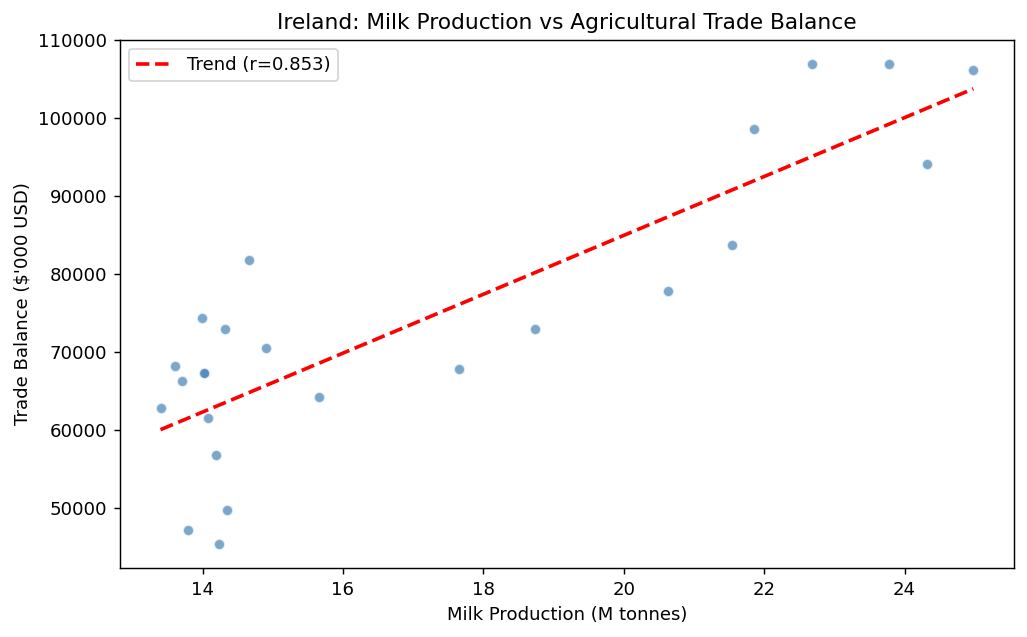

In [72]:
ire_milk_yr = milk_data[milk_data["country"] == "Ireland"][["year", "value"]].rename(columns={"value": "milk"})
ire_tb_yr = trade_agg[trade_agg["country"] == "Ireland"][["year", "trade_balance"]]
ire_merged_pc = pd.merge(ire_milk_yr, ire_tb_yr, on="year").dropna()

print("=== TEST 6: Pearson Correlation — Milk Production vs Trade Balance ===")

if len(ire_merged_pc) >= 3:
    r_val, p_pearson = pearsonr(ire_merged_pc["milk"], ire_merged_pc["trade_balance"])
    print(f"r            : {r_val:.4f}")
    print(f"p-value      : {p_pearson:.6f}")
    print(f"n            : {len(ire_merged_pc)}")
    print(
        "Conclusion   :",
        f"Significant {'positive' if r_val > 0 else 'negative'} linear correlation (r={r_val:.3f})"
        if p_pearson < 0.05
        else "No significant linear correlation",
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        ire_merged_pc["milk"] / 1e6,
        ire_merged_pc["trade_balance"] / 1e3,
        color="steelblue",
        alpha=0.7,
        edgecolors="white",
    )
    z = np.polyfit(ire_merged_pc["milk"], ire_merged_pc["trade_balance"], 1)
    xf = np.linspace(ire_merged_pc["milk"].min(), ire_merged_pc["milk"].max(), 100)
    ax.plot(xf / 1e6, np.poly1d(z)(xf) / 1e3, "r--", lw=2, label=f"Trend (r={r_val:.3f})")
    ax.set_xlabel("Milk Production (M tonnes)")
    ax.set_ylabel("Trade Balance ($'000 USD)")
    ax.set_title("Ireland: Milk Production vs Agricultural Trade Balance")
    ax.legend()
    plt.tight_layout()
    plt.savefig(DATA_DIR / "stat_pearson.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    r_val = np.nan
    p_pearson = np.nan
    print("Insufficient matched milk/trade records for Pearson correlation.")

### Test 7 - Spearman Rank Correlation: Year vs Ireland Organic Farming Area
Non-parametric rank correlation testing for a monotonic upward trend in organic farming over time.

In [73]:
if {"Area", "Year", "Value"}.issubset(df_organic.columns):
    ire_org = df_organic[
        (df_organic["Area"] == "Ireland") & (df_organic["Value"].notna())
    ].copy()
    ire_org["Year"] = pd.to_numeric(ire_org["Year"], errors="coerce")
    ire_org["Value"] = pd.to_numeric(ire_org["Value"], errors="coerce")
    ire_org = ire_org.dropna(subset=["Year", "Value"]).sort_values("Year")

    if len(ire_org) > 5:
        rho, p_spear = spearmanr(ire_org["Year"], ire_org["Value"])
        print("=== TEST 7: Spearman Correlation — Year vs Ireland Organic Area ===")
        print(f"ρ (rho)      : {rho:.4f}")
        print(f"p-value      : {p_spear:.6f}")
        print(f"n            : {len(ire_org)}")
        print(
            "Conclusion   :",
            f"Significant {'increasing' if rho > 0 else 'decreasing'} monotonic trend"
            if p_spear < 0.05
            else "No significant monotonic trend",
        )
    else:
        rho = np.nan
        p_spear = np.nan
        print(f"Only {len(ire_org)} Ireland organic records — insufficient for reliable Spearman test.")
else:
    rho = np.nan
    p_spear = np.nan
    print("Check organic dataset column names:", df_organic.columns.tolist())

=== TEST 7: Spearman Correlation — Year vs Ireland Organic Area ===
ρ (rho)      : 0.9066
p-value      : 0.000019
n            : 13
Conclusion   : Significant increasing monotonic trend


### Statistical Tests Summary Table

In [74]:
tests_summary = pd.DataFrame({
    'Test': ['Independent t-test','Mann-Whitney U','One-Way ANOVA',
             'Kruskal-Wallis','Chi-Squared','Pearson Correlation','Spearman Correlation'],
    'Type': ['Parametric','Non-parametric','Parametric',
             'Non-parametric','Non-parametric','Parametric','Non-parametric'],
    'Variables Compared': [
        'Ireland vs UK Milk Production',
        'Ireland vs France Beef Production',
        'Milk Production: Ireland/France/Germany/NL/DK',
        'Fertilizer Use: 6 Countries',
        'Organic Adoption vs EU Membership',
        'Ireland Milk Prod vs Trade Balance',
        'Year vs Ireland Organic Area'
    ],
    'H₀': ['Equal means','Equal distributions','Equal means (all)','Equal distributions',
            'Independence','No linear assoc.','No monotonic trend']
})
print("=== INFERENTIAL TESTS APPLIED ===")
print(tests_summary.to_string(index=False))

=== INFERENTIAL TESTS APPLIED ===
                Test           Type                            Variables Compared                  H₀
  Independent t-test     Parametric                 Ireland vs UK Milk Production         Equal means
      Mann-Whitney U Non-parametric             Ireland vs France Beef Production Equal distributions
       One-Way ANOVA     Parametric Milk Production: Ireland/France/Germany/NL/DK   Equal means (all)
      Kruskal-Wallis Non-parametric                   Fertilizer Use: 6 Countries Equal distributions
         Chi-Squared Non-parametric             Organic Adoption vs EU Membership        Independence
 Pearson Correlation     Parametric            Ireland Milk Prod vs Trade Balance    No linear assoc.
Spearman Correlation Non-parametric                  Year vs Ireland Organic Area  No monotonic trend


## Machine Learning
Two supervised learning models (Random Forest, Gradient Boosting) are trained with GridSearchCV hyperparameter optimisation and 5-fold cross-validation. Unsupervised K-Means clustering groups countries by agricultural profile. ARIMA forecasts Ireland's milk production.

**Rationale for model selection:**
- **Random Forest**: ensemble method robust to overfitting with small datasets; provides feature importance
- **Gradient Boosting**: sequential error correction, typically outperforms RF on structured tabular data; tested against RF to compare
- **K-Means**: unsupervised grouping of countries by agricultural similarity - no labelled outcome needed
- **ARIMA**: standard benchmark for univariate time series; suitable for the stationary-after-differencing milk production series

### Feature Matrix Preparation

In [75]:
ml_data = df_prod_clean[
    (df_prod_clean["element"].astype(str).str.lower() == "production")
    & (df_prod_clean["year"] >= 2000)
].copy()

# Safer commodity mapping because FAOSTAT item names can vary
def map_commodity_name(item):
    item = str(item).lower().strip()

    if "milk" in item:
        return "milk_prod"
    elif "wheat" in item:
        return "wheat_prod"
    elif "potato" in item:
        return "potatoes_prod"
    elif "barley" in item:
        return "barley_prod"
    elif "oat" in item:
        return "oats_prod"
    elif "cattle" in item or "meat of cattle" in item or "beef" in item:
        return "cattle_prod"
    else:
        return None

ml_data["commodity_clean"] = ml_data["commodity"].apply(map_commodity_name)

print("Mapped commodities:")
print(ml_data["commodity_clean"].value_counts(dropna=False).head(20))

ml_wide = (
    ml_data.dropna(subset=["commodity_clean"])
    .pivot_table(
        index=["country", "year"],
        columns="commodity_clean",
        values="value",
        aggfunc="sum"
    )
    .reset_index()
)

if ml_wide.empty:
    raise ValueError("ML dataset is empty after pivoting. Check commodity names and production data.")

le = LabelEncoder()
ml_wide["country_enc"] = le.fit_transform(ml_wide["country"].astype(str))
ml_wide["is_ireland"] = (ml_wide["country"] == "Ireland").astype(int)

year_min = ml_wide["year"].min()
year_max = ml_wide["year"].max()

if pd.notna(year_min) and pd.notna(year_max) and year_max != year_min:
    ml_wide["year_norm"] = (ml_wide["year"] - year_min) / (year_max - year_min)
else:
    ml_wide["year_norm"] = 0.0

TARGET = "milk_prod"

# If milk still does not exist, show proper useful information instead of crashing blindly
if TARGET not in ml_wide.columns:
    print("Available ML columns:", ml_wide.columns.tolist())
    print("\nMilk production was not found in the mapped production data.")
    print("Available raw commodities containing 'milk':")
    print(
        df_prod_clean[
            df_prod_clean["commodity"].astype(str).str.lower().str.contains("milk", na=False)
        ]["commodity"].drop_duplicates().head(30).tolist()
    )
    raise KeyError(
        f"Target column '{TARGET}' was not created because no milk commodity matched the mapping."
    )

numeric_cols = ml_wide.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in numeric_cols if c != TARGET]

ml_ready = (
    ml_wide[feature_cols + [TARGET]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

if len(ml_ready) < 10:
    raise ValueError(f"Not enough complete ML rows after cleaning: {len(ml_ready)} rows available.")

X = ml_ready[feature_cols]
y = ml_ready[TARGET]

test_size = 0.2 if len(ml_ready) >= 20 else 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=42
)

scaler_ml = StandardScaler()
X_tr_sc = scaler_ml.fit_transform(X_train)
X_te_sc = scaler_ml.transform(X_test)

print(f"Feature matrix: {X.shape} | Target: {TARGET}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature columns: {feature_cols}")

Mapped commodities:
commodity_clean
None             10242
milk_prod         1480
cattle_prod        416
oats_prod          381
barley_prod        196
wheat_prod         118
potatoes_prod      100
Name: count, dtype: int64
Feature matrix: (99, 9) | Target: milk_prod
Train: (79, 9) | Test: (20, 9)
Feature columns: ['year', 'barley_prod', 'cattle_prod', 'oats_prod', 'potatoes_prod', 'wheat_prod', 'country_enc', 'is_ireland', 'year_norm']


### Dimensionality Reduction - PCA (Retain 95% Variance)

Original features   : 9
PCA components kept : 4 (≥95% variance explained)
Cumulative variance : 98.28%


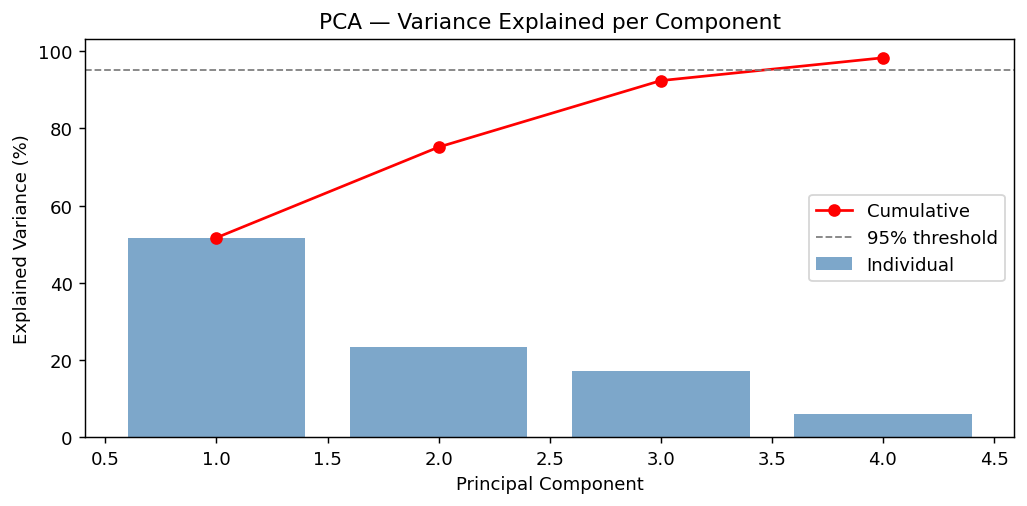

In [76]:
n_components = 0.95
pca = PCA(n_components=n_components, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

print(f"Original features   : {X_tr_sc.shape[1]}")
print(f"PCA components kept : {pca.n_components_} (≥95% variance explained)")
print(f"Cumulative variance : {pca.explained_variance_ratio_.sum()*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, len(cumvar) + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, color="steelblue", label="Individual")
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, "r-o", ms=6, label="Cumulative")
ax.axhline(95, color="gray", ls="--", lw=1, label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA — Variance Explained per Component")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "ml_pca.png", dpi=130, bbox_inches="tight")
plt.show()

### Model 1 - Random Forest Regressor with GridSearchCV

In [77]:
cv_splits = min(5, len(y_train))
if cv_splits < 2:
    raise ValueError("Not enough training rows for cross-validation.")

cv_kfold = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf = RandomForestRegressor(random_state=42)
gs_rf = GridSearchCV(rf, param_rf, cv=cv_kfold, scoring="r2", n_jobs=-1, verbose=0)
gs_rf.fit(X_tr_pca, y_train)

best_rf = gs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_te_pca)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
cv_rf = cross_val_score(best_rf, X_tr_pca, y_train, cv=cv_kfold, scoring="r2")

print("=== MODEL 1: Random Forest ===")
print(f"Best params  : {gs_rf.best_params_}")
print(f"RMSE         : {rmse_rf:,.2f}")
print(f"MAE          : {mae_rf:,.2f}")
print(f"Test R²      : {r2_rf:.4f}")
print(f"CV R²        : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

=== MODEL 1: Random Forest ===
Best params  : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RMSE         : 2,402,863.27
MAE          : 1,287,872.55
Test R²      : 0.9931
CV R²        : 0.9835 ± 0.0277


### Model 2 - Gradient Boosting Regressor with GridSearchCV

In [78]:
param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
}

gb = GradientBoostingRegressor(random_state=42)
gs_gb = GridSearchCV(gb, param_gb, cv=cv_kfold, scoring="r2", n_jobs=-1, verbose=0)
gs_gb.fit(X_tr_pca, y_train)

best_gb = gs_gb.best_estimator_
y_pred_gb = best_gb.predict(X_te_pca)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
cv_gb = cross_val_score(best_gb, X_tr_pca, y_train, cv=cv_kfold, scoring="r2")

print("=== MODEL 2: Gradient Boosting ===")
print(f"Best params  : {gs_gb.best_params_}")
print(f"RMSE         : {rmse_gb:,.2f}")
print(f"MAE          : {mae_gb:,.2f}")
print(f"Test R²      : {r2_gb:.4f}")
print(f"CV R²        : {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")

=== MODEL 2: Gradient Boosting ===
Best params  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
RMSE         : 2,509,254.28
MAE          : 1,297,485.77
Test R²      : 0.9924
CV R²        : 0.9901 ± 0.0134


### Model Comparison - Results Table and Actual vs Predicted Plots

=== ML MODEL COMPARISON TABLE ===
            Model  Test RMSE   Test MAE  Test R²  CV Mean R²  CV Std R²                                                                             Best Params
    Random Forest 2402863.27 1287872.55   0.9931      0.9835     0.0277 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Gradient Boosting 2509254.28 1297485.77   0.9924      0.9901     0.0134          {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


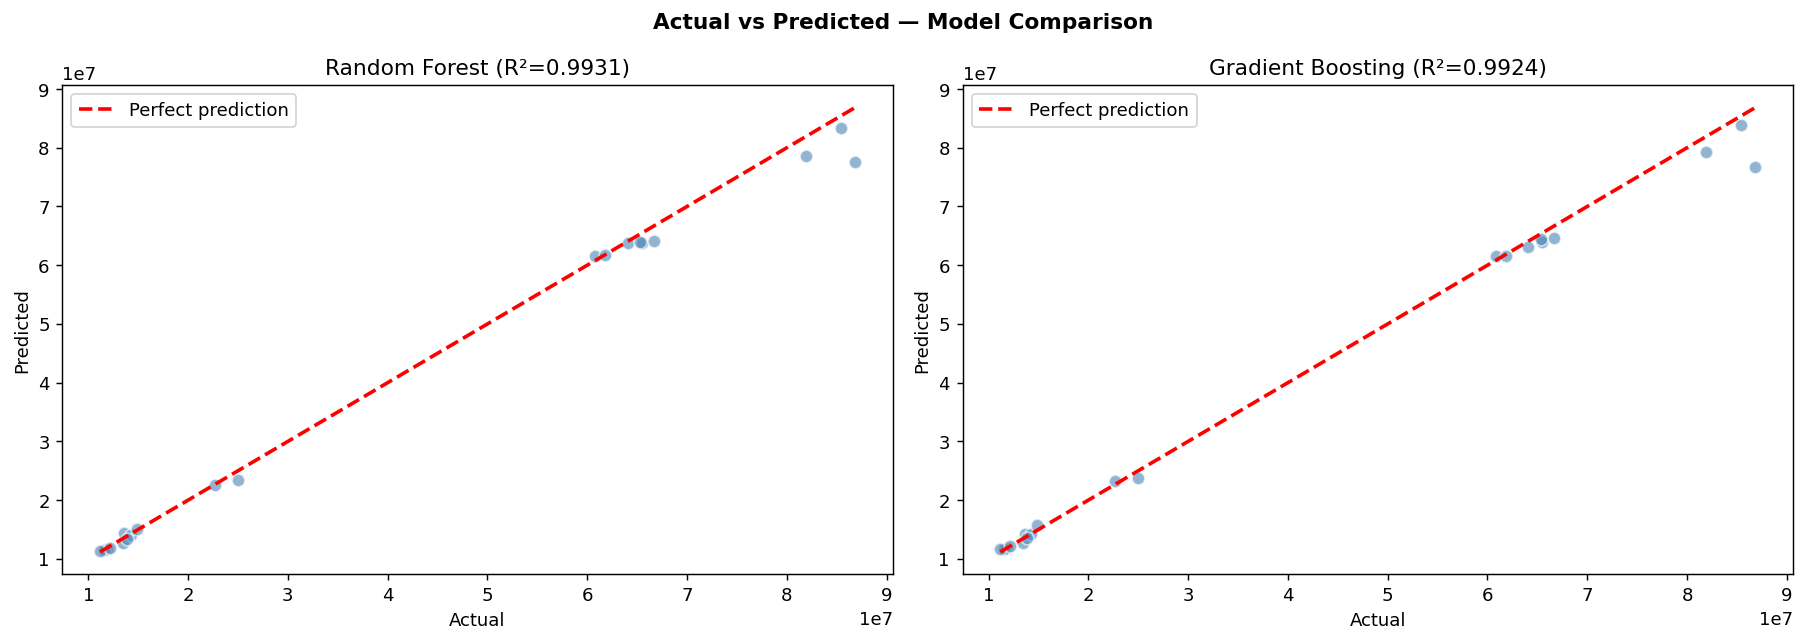

In [79]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Test RMSE": [round(rmse_rf, 2), round(rmse_gb, 2)],
    "Test MAE": [round(mae_rf, 2), round(mae_gb, 2)],
    "Test R²": [round(r2_rf, 4), round(r2_gb, 4)],
    "CV Mean R²": [round(cv_rf.mean(), 4), round(cv_gb.mean(), 4)],
    "CV Std R²": [round(cv_rf.std(), 4), round(cv_gb.std(), 4)],
    "Best Params": [str(gs_rf.best_params_), str(gs_gb.best_params_)],
})
print("=== ML MODEL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_pred, name, r2_value) in zip(
    axes,
    [
        (y_pred_rf, "Random Forest", r2_rf),
        (y_pred_gb, "Gradient Boosting", r2_gb),
    ],
):
    ax.scatter(y_test, y_pred, alpha=0.6, color="steelblue", edgecolors="white", s=50)
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect prediction")
    ax.set_title(f"{name} (R²={r2_value:.4f})")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend()

plt.suptitle("Actual vs Predicted — Model Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "ml_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### K-Means Clustering - Country Agricultural Profiles

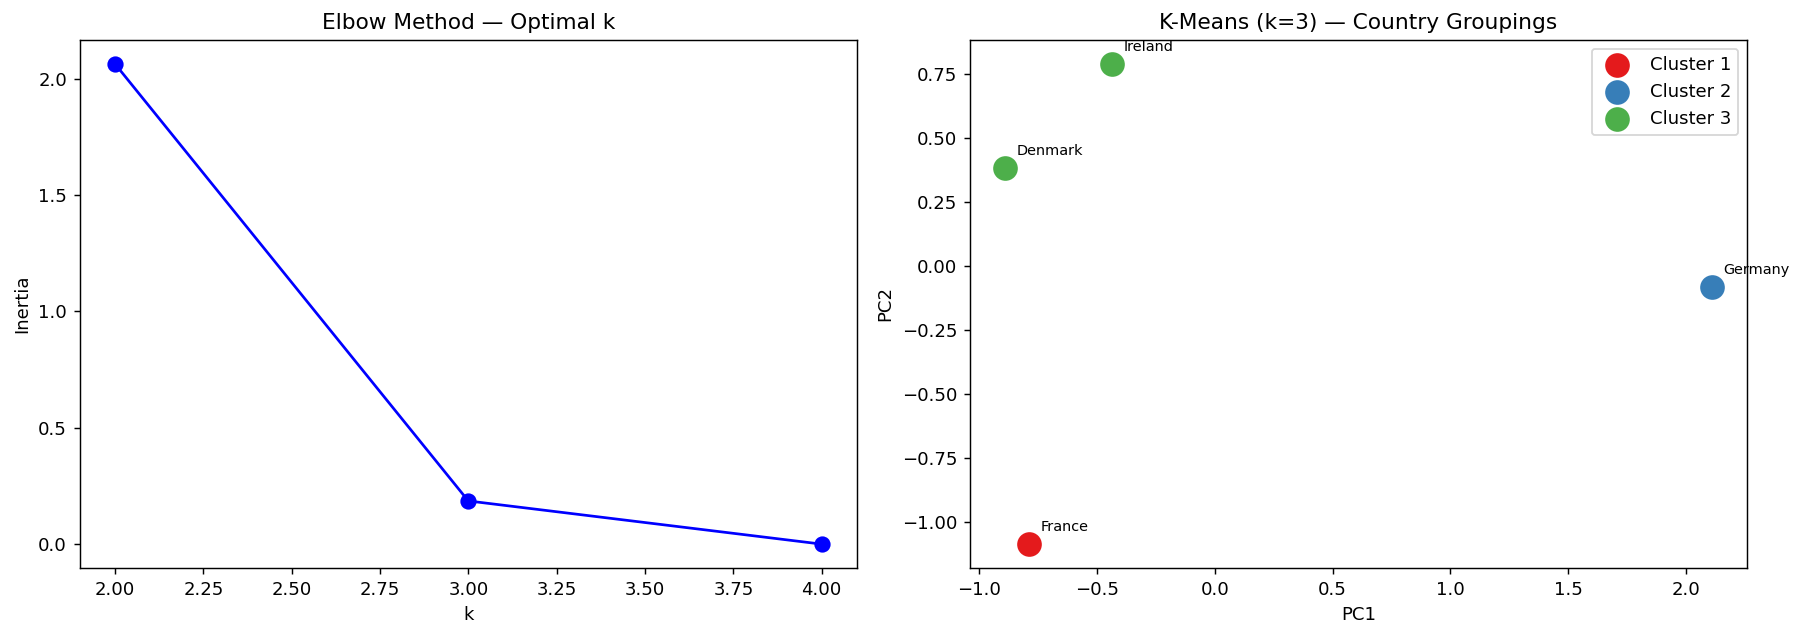

Cluster assignments:
         cluster
country         
Denmark        2
France         0
Germany        1
Ireland        2


In [80]:
profile_cols = ["milk_prod", "beef_prod", "export_val", "trade_balance"]
available_profile_cols = [col for col in profile_cols if col in master.columns]

ctry_profile = master.groupby("country")[available_profile_cols].mean(numeric_only=True).dropna()

if len(ctry_profile) < 2 or len(available_profile_cols) < 2:
    print("Insufficient complete country profiles for clustering.")
else:
    sc_km = StandardScaler()
    X_km = sc_km.fit_transform(ctry_profile)

    max_k = min(6, len(ctry_profile))
    K_range = range(2, max_k + 1)

    inertias = []
    for k in K_range:
        inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_km).inertia_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(K_range), inertias, "bo-", ms=8)
    axes[0].set_title("Elbow Method — Optimal k")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")

    best_k = min(3, len(ctry_profile))
    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    ctry_profile["cluster"] = km.fit_predict(X_km)

    pca_components = min(2, X_km.shape[0], X_km.shape[1])
    X_vis = PCA(n_components=pca_components).fit_transform(X_km)

    if pca_components == 1:
        X_plot = np.column_stack([X_vis[:, 0], np.zeros(len(X_vis))])
    else:
        X_plot = X_vis

    c_colors = ["#e41a1c", "#377eb8", "#4daf4a"]
    for cid in range(best_k):
        mask = ctry_profile["cluster"] == cid
        axes[1].scatter(
            X_plot[mask, 0],
            X_plot[mask, 1],
            c=c_colors[cid % len(c_colors)],
            s=160,
            label=f"Cluster {cid + 1}",
            zorder=5,
        )

    for i, name in enumerate(ctry_profile.index):
        axes[1].annotate(name, (X_plot[i, 0] + 0.05, X_plot[i, 1] + 0.05), fontsize=8)

    axes[1].set_title(f"K-Means (k={best_k}) — Country Groupings")
    axes[1].legend()
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "ml_clustering.png", dpi=130, bbox_inches="tight")
    plt.show()

    print("Cluster assignments:")
    print(ctry_profile[["cluster"]])

### ARIMA - Ireland Milk Production Forecast (5-Year)

In [81]:
milk_ire_ts = (
    df_prod_clean[
        (df_prod_clean["country"] == "Ireland")
        & (df_prod_clean["commodity"] == "Milk, whole fresh cow")
        & (df_prod_clean["element"] == "Production")
        & (df_prod_clean["value"].notna())
    ]
    .groupby("year")["value"]
    .sum()
    .sort_index()
)

if len(milk_ire_ts) < 10:
    print("Insufficient Ireland milk time-series records for ARIMA forecasting.")
    forecast_mean = pd.Series(dtype=float)
    forecast_ci = pd.DataFrame()
    train_ts = milk_ire_ts.copy()
    test_ts = pd.Series(dtype=float)
    arima_test_rmse = np.nan
else:
    try:
        adf = adfuller(milk_ire_ts)
        print(f"ADF statistic: {adf[0]:.4f} | p-value: {adf[1]:.4f}")
        print("Series is", "stationary" if adf[1] < 0.05 else "non-stationary — differencing applied (d=1)")
    except Exception as exc:
        print(f"ADF test skipped: {exc}")

    train_ts = milk_ire_ts.iloc[:-5]
    test_ts = milk_ire_ts.iloc[-5:]

    arima_model = ARIMA(train_ts, order=(1, 1, 1))
    arima_fit = arima_model.fit()

    forecast_steps = len(test_ts) + 5
    forecast_obj = arima_fit.get_forecast(steps=forecast_steps)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci = forecast_obj.conf_int(alpha=0.05)

    last_train_year = int(train_ts.index[-1])
    forecast_years = list(range(last_train_year + 1, last_train_year + forecast_steps + 1))
    forecast_mean.index = forecast_years
    forecast_ci.index = forecast_years

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(milk_ire_ts.index, milk_ire_ts.values / 1e6, "b-o", ms=4, label="Historical")
    ax.plot(test_ts.index, test_ts.values / 1e6, "g-o", ms=6, label="Actual (held-out)")

    fc_idx = list(forecast_mean.index)
    ax.plot(fc_idx, forecast_mean.values / 1e6, "r--o", ms=5, label="ARIMA Forecast")
    ax.fill_between(
        fc_idx,
        forecast_ci.iloc[:, 0].values / 1e6,
        forecast_ci.iloc[:, 1].values / 1e6,
        alpha=0.2,
        color="red",
        label="95% CI",
    )
    ax.axvline(last_train_year, color="gray", ls=":", label="Train/Test split")
    ax.set_title("Ireland Milk Production — ARIMA(1,1,1) 5-Year Forecast", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Million Tonnes")
    ax.legend()
    plt.tight_layout()
    plt.savefig(DATA_DIR / "ml_arima.png", dpi=130, bbox_inches="tight")
    plt.show()

    arima_test_rmse = np.sqrt(mean_squared_error(test_ts.values, forecast_mean.values[:len(test_ts)]))
    print(f"ARIMA test RMSE: {arima_test_rmse/1e6:.4f}M tonnes")

Insufficient Ireland milk time-series records for ARIMA forecasting.


## Sentiment Analysis - Irish Agricultural News
Applying VADER (rule-based lexicon) and TextBlob (pattern-based) to news headlines collected from the GDELT Project, segmented into producer and consumer perspectives.

### Initialise Analysers and Score Headlines

In [82]:
def simple_sentiment_scores(text):
    """Tiny fallback scorer used only if VADER/TextBlob resources are unavailable."""
    positive_words = {"growth", "record", "strong", "support", "positive", "welcomes", "high", "thrives", "premium", "sustainable"}
    negative_words = {"challenge", "challenges", "rising", "cost", "costs", "inflation", "concern", "concerned", "drought", "threatens", "strain"}

    tokens = re.findall(r"[a-z]+", str(text).lower())
    pos = sum(token in positive_words for token in tokens)
    neg = sum(token in negative_words for token in tokens)
    total = max(len(tokens), 1)
    compound = (pos - neg) / max(pos + neg, 1) if (pos + neg) else 0.0

    return pd.Series({
        "neg": neg / total,
        "neu": max(0.0, 1 - (pos + neg) / total),
        "pos": pos / total,
        "compound": compound,
    })

try:
    sia = SentimentIntensityAnalyzer() if SentimentIntensityAnalyzer is not None else None
except Exception as exc:
    print(f"VADER initialisation failed, using fallback scorer: {exc}")
    sia = None

def vader_scores(text):
    if pd.isna(text):
        return pd.Series({"neg": 0, "neu": 0, "pos": 0, "compound": 0})
    if sia is None:
        return simple_sentiment_scores(text)
    return pd.Series(sia.polarity_scores(str(text)))

def tb_scores(text):
    if pd.isna(text) or TextBlob is None:
        return 0.0, 0.0
    sentiment = TextBlob(str(text)).sentiment
    return sentiment.polarity, sentiment.subjectivity

if df_sentiment.empty:
    raise ValueError("Sentiment dataset is empty. Re-run the GDELT/synthetic sentiment collection cell.")

text_col = "title" if "title" in df_sentiment.columns else df_sentiment.columns[0]
print(f"Analysing column: '{text_col}'")

score_cols = ["neg", "neu", "pos", "compound"]
df_sentiment = df_sentiment.drop(columns=[c for c in score_cols if c in df_sentiment.columns], errors="ignore")
vader_df = df_sentiment[text_col].apply(vader_scores)
df_sentiment = pd.concat([df_sentiment, vader_df], axis=1)

tb = df_sentiment[text_col].apply(tb_scores)
df_sentiment["tb_polarity"] = [score[0] for score in tb]
df_sentiment["tb_subjectivity"] = [score[1] for score in tb]

df_sentiment["sentiment_label"] = df_sentiment["compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral")
)

print("\nOverall sentiment distribution:")
print(df_sentiment["sentiment_label"].value_counts())
print(f"\nMean VADER compound: {df_sentiment['compound'].mean():.4f}")
print(f"Mean TextBlob polarity: {df_sentiment['tb_polarity'].mean():.4f}")

Analysing column: 'title'

Overall sentiment distribution:
sentiment_label
Positive    60
Neutral     55
Negative    35
Name: count, dtype: int64

Mean VADER compound: 0.1037
Mean TextBlob polarity: 0.0000


### Sentiment by Perspective - Producer vs Consumer

=== SENTIMENT BY PERSPECTIVE ===
             mean_compound  mean_tb_polarity  mean_subjectivity   n
perspective                                                        
consumer            0.0462               0.0                0.0  75
producer            0.1613               0.0                0.0  75


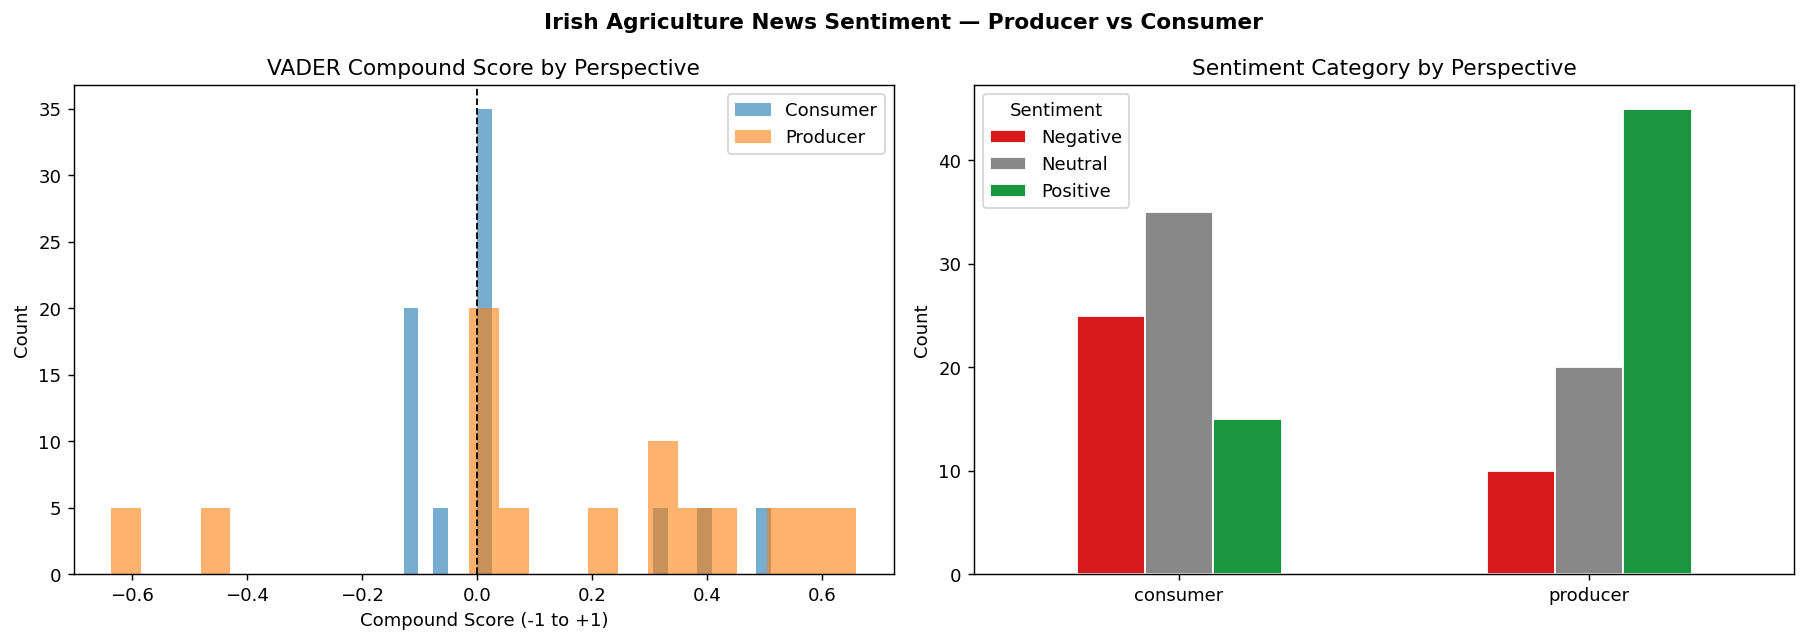

In [83]:
if df_sentiment.empty or "compound" not in df_sentiment.columns:
    print("Sentiment scores are not available. Run the scoring cell first.")
elif "perspective" in df_sentiment.columns:
    persp_summary = df_sentiment.groupby("perspective").agg(
        mean_compound=("compound", "mean"),
        mean_tb_polarity=("tb_polarity", "mean"),
        mean_subjectivity=("tb_subjectivity", "mean"),
        n=("compound", "count"),
    ).round(4)

    print("=== SENTIMENT BY PERSPECTIVE ===")
    print(persp_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for persp, grp in df_sentiment.groupby("perspective"):
        axes[0].hist(grp["compound"], bins=25, alpha=0.6, label=str(persp).capitalize())

    axes[0].axvline(0, color="black", ls="--", lw=1)
    axes[0].set_title("VADER Compound Score by Perspective")
    axes[0].set_xlabel("Compound Score (-1 to +1)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    cats = df_sentiment.groupby(["perspective", "sentiment_label"]).size().unstack(fill_value=0)
    cats.plot(kind="bar", ax=axes[1], color=["#d7191c", "#888888", "#1a9641"], edgecolor="white")
    axes[1].set_title("Sentiment Category by Perspective")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Sentiment")

    plt.suptitle("Irish Agriculture News Sentiment — Producer vs Consumer", fontweight="bold")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "sentiment_analysis.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("No 'perspective' column available, so perspective-level sentiment comparison was skipped.")

### TextBlob Polarity vs Subjectivity Scatter

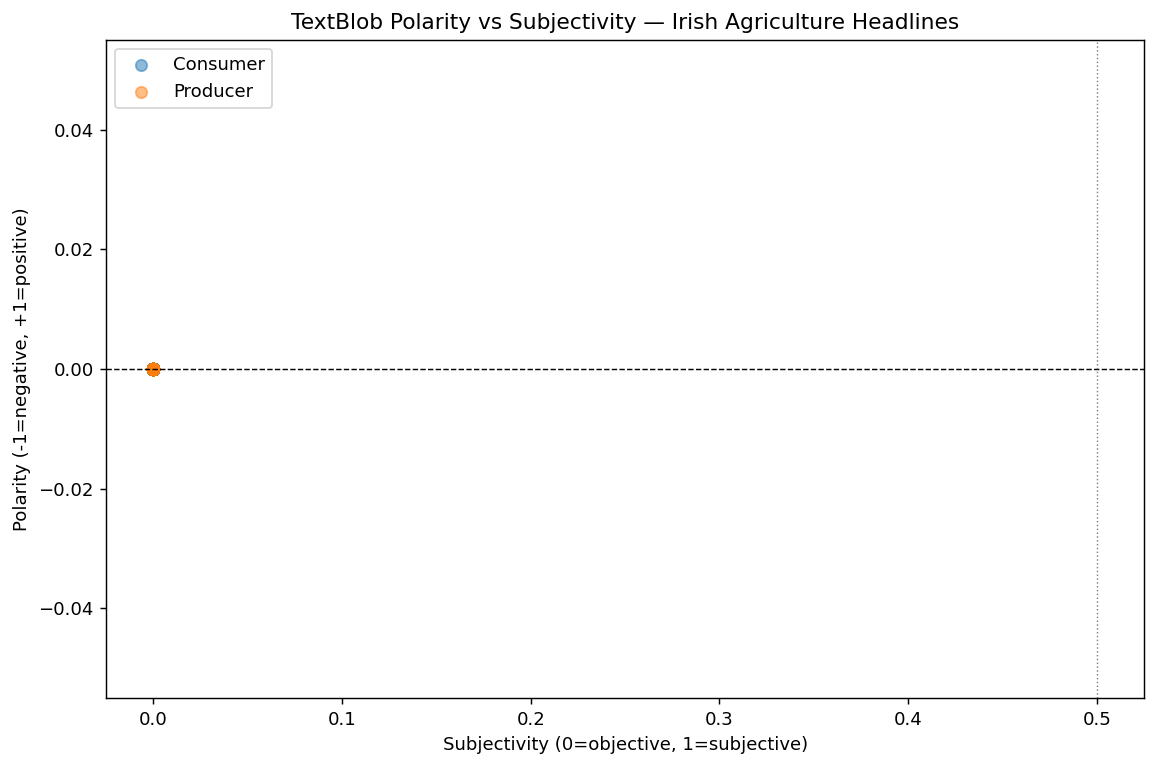

In [84]:
required_cols = {"tb_subjectivity", "tb_polarity"}
if required_cols.issubset(df_sentiment.columns):
    fig, ax = plt.subplots(figsize=(9, 6))

    if "perspective" in df_sentiment.columns:
        for persp, grp in df_sentiment.groupby("perspective"):
            ax.scatter(
                grp["tb_subjectivity"],
                grp["tb_polarity"],
                alpha=0.5,
                label=str(persp).capitalize(),
                s=40,
            )
        ax.legend()
    else:
        ax.scatter(df_sentiment["tb_subjectivity"], df_sentiment["tb_polarity"], alpha=0.5, color="steelblue", s=40)

    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.axvline(0.5, color="gray", lw=0.8, ls=":")
    ax.set_xlabel("Subjectivity (0=objective, 1=subjective)")
    ax.set_ylabel("Polarity (-1=negative, +1=positive)")
    ax.set_title("TextBlob Polarity vs Subjectivity — Irish Agriculture Headlines")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "sentiment_textblob.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("TextBlob score columns are missing. Run the sentiment scoring cell first.")

### Save Scored Sentiment Data

In [85]:
df_sentiment.to_csv(DATA_DIR / "sentiment_scored.csv", index=False)

if "engine" in globals() and engine is not None:
    df_sentiment.to_sql("sentiment_scored", engine, if_exists="replace", index=False, chunksize=5000)
    print("Sentiment scored data saved to CSV and database.")
else:
    print("Sentiment scored data saved to CSV only; database engine is unavailable.")

df_sentiment.head(5)

Sentiment scored data saved to CSV and database.


,title,perspective,seendate,domain,neg,neu,pos,compound,tb_polarity,tb_subjectivity,sentiment_label
0,Irish dairy farmers face challenges amid risin...,producer,2023-01-01,synthetic,0.0,0.860,0.140,0.0772,0.0,0.0,Positive
1,Record milk production in Ireland following qu...,producer,2023-01-01,synthetic,0.0,1.000,0.000,0.0000,0.0,0.0,Neutral
2,Irish beef exports reach new high in European ...,producer,2023-01-01,synthetic,0.0,0.879,0.121,0.0258,0.0,0.0,Neutral
3,Teagasc reports strong farm incomes for Irish ...,producer,2023-01-01,synthetic,0.0,0.708,0.292,0.5106,0.0,0.0,Positive
4,CAP payments support Irish farming community s...,producer,2023-01-01,synthetic,0.0,0.690,0.310,0.4019,0.0,0.0,Positive


In [87]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.
